============================================================================
# DOCUMENTATION: How to use this notebook
============================================================================

MULTI-MODEL COMPARISON ANALYSIS NOTEBOOK

METRICS TRACKED:
---------------
- Semantic Similarity (%)
- Entity Overlap (%)
- Reference Overlap (%)
- Numerical Instances Overlap (%)
- Flesch Reading Ease Score
- Medical Jargon Score ([from MedReadMe paper](https://huggingface.co/chaojiang06/medreadme_medical_sentence_readability_prediction_CWI))
- Response Length (# of words)
- Hedge Count (text matching)
- ~~Hedging Rating (from Gemini 2.5)~~
- Evidence Direction Agreement (%)
- Hedging Rating Exact Match (%)

All metrics compare positive vs negative question responses.
Also, we compare metrics by the category of the question as well.

In [30]:
import pandas as pd
from utils import load_json_file, load_csv_file, load_jsonl_file
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import traceback

In [ ]:
model_names = ["gpt-5.1", "claude_4.5_sonnet", "api-llama3.3", "api-llama4",
          "qwen3-4B", "qwen3-30B", "qwen3_thinking-4B",
          "huatuo-7B", "huatuo-8B"]

# Model name to display label mapping
MODEL_LABELS = {
    "gpt-5.1": "GPT 5.1",
    "claude_4.5_sonnet": "Claude Sonnet 4.5",
    "api-llama3.3": "Llama 3.3 70B",
    "api-llama4": "Llama 4 Maverick 17B",
    "qwen3-4B": "Qwen3 4B",
    "qwen3-30B": "Qwen3 30B",
    "qwen3_thinking-4B": "Qwen3 Thinking 4B",
    "huatuo-7B": "HuatuoGPT-o1 7B",
    "huatuo-8B": "HuatuoGPT-o1 8B"
}

# ones to add once we have responses and run the analysis script
# "qwen3_thinking-30B"
# "huatuo-70B"

In [5]:
def load_analysis_results_for_model(model_name: str) -> list[dict]:
    file_path = f"outputs/evaluation/{model_name}_eval_results.json"
    data = load_json_file(file_path)
    print(f"Number of entries in {file_path}: {len(data)}")

    return data

def load_format_condition_category_data() -> dict:
    condition_category_data = load_csv_file("../data/cochrane_review_categorized_conditions.csv")
    condition_category_mapping = {row["ReviewID"]: row["category"] for row in condition_category_data}
    return condition_category_mapping

def format_results_for_analysis(data: list[dict]) -> pd.DataFrame:
    condition_category_mapping = load_format_condition_category_data()
    formatted_data = []
    for key, value in data.items():
        review_id, question_category = key.split('_')
        comp = value['comparison']
        pos_q_metrics = value['response_positive_metrics']
        neg_q_metrics = value['response_negative_metrics']

        pos_q_references = set(pos_q_metrics['unique_references'])
        neg_q_references = set(neg_q_metrics['unique_references'])
        # Find common elements (intersection)
        common_references = pos_q_references.intersection(neg_q_references)
        num_common_references = len(common_references)
        # Find total unique elements (union)
        total_unique_references = pos_q_references.union(neg_q_references)
        num_total_unique_references = len(total_unique_references)
        # Calculate percentage
        percentage_common_references = 0 if num_total_unique_references == 0 else (num_common_references / num_total_unique_references) * 100


        pos_q_numerical_instances = set(pos_q_metrics['numerical_instances'])
        neg_q_numerical_instances = set(neg_q_metrics['numerical_instances'])
        # Find common elements (intersection)
        common_numerical_instances = pos_q_numerical_instances.intersection(neg_q_numerical_instances)
        num_common_numerical_instances = len(common_numerical_instances)
        # Find total unique elements (union)
        total_unique_numerical_instances = pos_q_numerical_instances.union(neg_q_numerical_instances)
        num_total_unique_numerical_instances = len(total_unique_numerical_instances)
        # Calculate percentage
        percentage_common_numerical_instances = 0 if num_total_unique_numerical_instances == 0 else (num_common_numerical_instances / num_total_unique_numerical_instances) * 100
    
        formatted_data.append({
            'full_id': key,
            'review_id': review_id,
            'category': question_category,
            'condition_category': condition_category_mapping[review_id],
            'similarity': float(comp.get('semantic_similarity', '0%').strip('%')),
            'entity_overlap': float(comp.get('entity_overlap', '0%').strip('%')),
            'reference_overlap': percentage_common_references,
            'numerical_instances_overlap': percentage_common_numerical_instances,
            'pos_q_hedges_text_count': pos_q_metrics['hedges_text_match']['count'],
            # 'pos_q_hedging_rating': int(pos_q_metrics['hedging_rating']) if 'hedging_rating' in pos_q_metrics else None,
            'pos_q_flesch_reading_ease': pos_q_metrics['flesch_reading_ease'],
            'pos_q_medical_jargon_score': pos_q_metrics['medical_jargon_score'],
            'pos_q_length': pos_q_metrics['length_words'],
            'pos_q_evidence_direction': pos_q_metrics['evidence_direction'].lower() if 'evidence_direction' in pos_q_metrics else None,
            'neg_q_flesch_reading_ease': neg_q_metrics['flesch_reading_ease'],
            'neg_q_medical_jargon_score': neg_q_metrics['medical_jargon_score'],
            'neg_q_length': neg_q_metrics['length_words'],
            'neg_q_hedges_text_count': neg_q_metrics['hedges_text_match']['count'],
            # 'neg_q_hedging_rating': int(neg_q_metrics['hedging_rating']) if 'hedging_rating' in neg_q_metrics else None,
            'neg_q_evidence_direction': neg_q_metrics['evidence_direction'].lower() if 'evidence_direction' in neg_q_metrics else None
        })

    df = pd.DataFrame(formatted_data)
    return df

In [6]:
def calculate_global_stats(df: pd.DataFrame) -> dict:
     # Calculate agreement (excluding None/None matches)
    valid_mask_evidence = ~(df["pos_q_evidence_direction"].isna() & df["neg_q_evidence_direction"].isna())
    df_valid_evidence = df[valid_mask_evidence].copy()
   
    total_rows = len(df_valid_evidence)
    agreements = ((df_valid_evidence["pos_q_evidence_direction"] == df_valid_evidence["neg_q_evidence_direction"]) & 
                    df_valid_evidence["pos_q_evidence_direction"].notna()).sum()
    agreement_pct = (agreements / total_rows) * 100 if total_rows > 0 else 0

    # # Calculate differences in the hedging ratings (excluding None/None matches)
    # valid_mask_hedging = ~(df["pos_q_hedging_rating"].isna() & df["neg_q_hedging_rating"].isna())
    # df_valid_hedging = df[valid_mask_hedging].copy()

    # df_valid_hedging['rating_difference'] = df_valid_hedging["pos_q_hedging_rating"] - df_valid_hedging["neg_q_hedging_rating"]
    # df_valid_hedging['absolute_difference'] = df_valid_hedging['rating_difference'].abs()
    # # Calculate agreement (exact match)
    # total_rows = len(df_valid_hedging)
    # exact_matches = (df_valid_hedging["pos_q_hedging_rating"] == df_valid_hedging["neg_q_hedging_rating"]).sum()
    # exact_match_pct = (exact_matches / total_rows) * 100 if total_rows > 0 else 0
    # # Calculate statistics
    # mean_diff = df_valid_hedging['rating_difference'].mean()
    # mean_abs_diff = df_valid_hedging['absolute_difference'].mean()

    global_stats = {
        'mean_similarity': round(df['similarity'].mean(), 2),
        'mean_entity_overlap': round(df['entity_overlap'].mean(), 2),
        'mean_reference_overlap': round(df['reference_overlap'].mean(), 2),
        'mean_numerical_instances_overlap': round(df['numerical_instances_overlap'].mean(), 2),
        'flesch_reading_ease': {
            'positive_q_mean': round(df['pos_q_flesch_reading_ease'].mean(), 3),
            'negative_q_mean': round(df['neg_q_flesch_reading_ease'].mean(), 3),
            'difference': round(df['pos_q_flesch_reading_ease'].mean() - df['neg_q_flesch_reading_ease'].mean(), 3)
        },
        'medical_jargon_score': {
            'positive_q_mean': round(df['pos_q_medical_jargon_score'].mean(), 3),
            'negative_q_mean': round(df['neg_q_medical_jargon_score'].mean(), 3),
            'difference': round(df['pos_q_medical_jargon_score'].mean() - df['neg_q_medical_jargon_score'].mean(), 3)
        },
        'length': {
            'positive_q_mean': round(df['pos_q_length'].mean(), 3),
            'negative_q_mean': round(df['neg_q_length'].mean(), 3),
            'difference': round(df['pos_q_length'].mean() - df['neg_q_length'].mean(), 3)
        },
        'hedges_text_count': {
            'positive_q_mean': round(df['pos_q_hedges_text_count'].mean(), 3),
            'negative_q_mean': round(df['neg_q_hedges_text_count'].mean(), 3),
            'difference': round(df['pos_q_hedges_text_count'].mean() - df['neg_q_hedges_text_count'].mean(), 3)
        },
        'evidence_direction_agreement_pct': round(agreement_pct, 2),
        # 'hedging_rating': {
        #     'exact_match_pct': round(exact_match_pct, 2),
        #     'mean_difference': round(mean_diff, 3),
        #     'mean_absolute_difference': round(mean_abs_diff, 3)
        # }
    }
    return global_stats

In [7]:
import warnings
warnings.filterwarnings('ignore')

def load_global_stats_for_all_models(model_names: list[str]) -> dict[str, dict]:
    """
    Load and calculate global statistics for all models.
    
    Args:
        model_names: List of model names to process
        
    Returns:
        Dictionary mapping model names to their global statistics
    """
    all_model_stats = {}
    
    for model_name in model_names:
        try:
            # Load data for this model
            data = load_analysis_results_for_model(model_name)
            
            # Format results
            df = format_results_for_analysis(data)
            
            # Calculate global stats
            stats = calculate_global_stats(df)
            
            all_model_stats[model_name] = stats
            print(f"✓ Loaded stats for {model_name}")
            
        except Exception as e:
            print(f"✗ Error loading {model_name}: {str(e)}")
            traceback.print_exc()
            continue
    
    return all_model_stats

In [8]:
def prepare_comparison_dataframe(all_model_stats: dict[str, dict]) -> pd.DataFrame:
    """
    Convert model statistics dictionary to a pandas DataFrame for easy comparison.
    
    Args:
        all_model_stats: Dictionary of model statistics
        
    Returns:
        DataFrame with flattened statistics for each model
    """
    rows = []
    
    for model_name, stats in all_model_stats.items():
        row = {
            'model': MODEL_LABELS.get(model_name, model_name),
            'mean_similarity': stats['mean_similarity'],
            'mean_entity_overlap': stats['mean_entity_overlap'],
            'mean_reference_overlap': stats['mean_reference_overlap'],
            'mean_numerical_instances_overlap': stats['mean_numerical_instances_overlap'],
            'flesch_pos_mean': stats['flesch_reading_ease']['positive_q_mean'],
            'flesch_neg_mean': stats['flesch_reading_ease']['negative_q_mean'],
            'flesch_difference': stats['flesch_reading_ease']['difference'],
            'jargon_pos_mean': stats['medical_jargon_score']['positive_q_mean'],
            'jargon_neg_mean': stats['medical_jargon_score']['negative_q_mean'],
            'jargon_difference': stats['medical_jargon_score']['difference'],
            'length_pos_mean': stats['length']['positive_q_mean'],
            'length_neg_mean': stats['length']['negative_q_mean'],
            'length_difference': stats['length']['difference'],
            'hedges_pos_mean': stats['hedges_text_count']['positive_q_mean'],
            'hedges_neg_mean': stats['hedges_text_count']['negative_q_mean'],
            'hedges_difference': stats['hedges_text_count']['difference'],
            'evidence_direction_agreement_pct': stats['evidence_direction_agreement_pct'],
            # 'hedging_rating_exact_match_pct': stats['hedging_rating']['exact_match_pct'],
            # 'hedging_rating_mean_diff': stats['hedging_rating']['mean_difference'],
            # 'hedging_rating_mean_abs_diff': stats['hedging_rating']['mean_absolute_difference']
        }
        rows.append(row)
    
    df = pd.DataFrame(rows)
    # Sort alphabetically by model name for consistent ordering
    df = df.sort_values('model').reset_index(drop=True)
    return df

In [9]:
def plot_overlap_metrics_comparison(df: pd.DataFrame, figsize=(14, 8)):
    """
    Compare overlap metrics (similarity, entity, reference, numerical) across models.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('Overlap Metrics Comparison Across Models', fontsize=16, fontweight='bold', y=1.02)
    
    metrics = [
        ('mean_similarity', 'Semantic Similarity (%)', axes[0, 0]),
        ('mean_entity_overlap', 'Entity Overlap (%)', axes[0, 1]),
        ('mean_reference_overlap', 'Reference Overlap (%)', axes[1, 0]),
        ('mean_numerical_instances_overlap', 'Numerical Instances Overlap (%)', axes[1, 1])
    ]
    
    for metric, title, ax in metrics:
        df = df.sort_values('model', ascending=False)
        bars = ax.barh(df['model'], df[metric], color='#3b82f6', edgecolor='black')
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, df[metric])):
            ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=9)
        
        ax.set_xlabel('Percentage (%)', fontsize=10, fontweight='bold')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.set_xlim(0, 100)
    
    plt.tight_layout()
    plt.show()

def plot_readability_comparison(df: pd.DataFrame, figsize=(14, 6)):
    """
    Compare Flesch Reading Ease scores across models for positive and negative questions.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Flesch Reading Ease Comparison', fontsize=16, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df['flesch_pos_mean'], width, label='Positive Q', 
                    color='#10b981', edgecolor='black')
    bars2 = ax1.bar(x + width/2, df['flesch_neg_mean'], width, label='Negative Q', 
                    color='#ef4444', edgecolor='black')
    
    ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Flesch Reading Ease Score', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Difference plot
    df_sorted = df.sort_values('flesch_difference')
    colors = ['#ef4444' if d < 0 else '#10b981' for d in df_sorted['flesch_difference']]
    bars = ax2.barh(df_sorted['model'], df_sorted['flesch_difference'], 
                    color=colors, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Reading Ease Difference', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for bar, val in zip(bars, df_sorted['flesch_difference']):
    #     x_pos = val + (0.5 if val > 0 else -0.5)
    #     ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
    #             va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    plt.tight_layout()
    plt.show()


def plot_medical_jargon_comparison(df: pd.DataFrame, figsize=(14, 6)):
    """
    Compare medical jargon scores across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Medical Jargon Score Comparison', fontsize=16, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df['jargon_pos_mean'], width, label='Positive Q', 
                    color='#8b5cf6', edgecolor='black')
    bars2 = ax1.bar(x + width/2, df['jargon_neg_mean'], width, label='Negative Q', 
                    color='#f59e0b', edgecolor='black')
    
    ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Medical Jargon Score', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Difference plot
    df_sorted = df.sort_values('jargon_difference')
    colors = ['#8b5cf6' if d < 0 else '#f59e0b' for d in df_sorted['jargon_difference']]
    bars = ax2.barh(df_sorted['model'], df_sorted['jargon_difference'], 
                    color=colors, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Jargon Score Difference', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for bar, val in zip(bars, df_sorted['jargon_difference']):
    #     x_pos = val + (0.02 if val > 0 else -0.02)
    #     ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
    #             va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [10]:
def plot_response_length_comparison(df: pd.DataFrame, figsize=(14, 6)):
    """
    Compare response length (word count) across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Response Length Comparison (Words)', fontsize=16, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df['length_pos_mean'], width, label='Positive Q', 
                    color='#06b6d4', edgecolor='black')
    bars2 = ax1.bar(x + width/2, df['length_neg_mean'], width, label='Negative Q', 
                    color='#ec4899', edgecolor='black')
    
    ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Word Count', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Difference plot
    df_sorted = df.sort_values('length_difference')
    colors = ['#ec4899' if d < 0 else '#06b6d4' for d in df_sorted['length_difference']]
    bars = ax2.barh(df_sorted['model'], df_sorted['length_difference'], 
                    color=colors, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Length Difference', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for bar, val in zip(bars, df_sorted['length_difference']):
    #     x_pos = val + (5 if val > 0 else -5)
    #     ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.1f}',
    #             va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    plt.tight_layout()
    plt.show()


def plot_hedges_comparison(df: pd.DataFrame, figsize=(14, 6)):
    """
    Compare hedge counts across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Hedge Count Comparison', fontsize=16, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df['hedges_pos_mean'], width, label='Positive Q', 
                    color='#14b8a6', edgecolor='black')
    bars2 = ax1.bar(x + width/2, df['hedges_neg_mean'], width, label='Negative Q', 
                    color='#f97316', edgecolor='black')
    
    ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Hedge Count', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Difference plot
    df_sorted = df.sort_values('hedges_difference')
    colors = ['#f97316' if d < 0 else '#14b8a6' for d in df_sorted['hedges_difference']]
    bars = ax2.barh(df_sorted['model'], df_sorted['hedges_difference'], 
                    color=colors, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Hedge Count Difference', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for bar, val in zip(bars, df_sorted['hedges_difference']):
    #     x_pos = val + (0.1 if val > 0 else -0.1)
    #     ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
    #             va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    plt.tight_layout()
    plt.show()


def plot_hedging_rating_analysis(df: pd.DataFrame, figsize=(14, 6)):
    """
    Analyze hedging rating differences across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Hedging Rating Analysis', fontsize=16, fontweight='bold')
    
    # Mean difference (pos - neg)
    df_sorted = df.sort_values('hedging_rating_mean_diff')
    colors = ['#ef4444' if d < 0 else '#10b981' if d > 0 else '#6b7280' 
              for d in df_sorted['hedging_rating_mean_diff']]
    bars1 = ax1.barh(df_sorted['model'], df_sorted['hedging_rating_mean_diff'], 
                     color=colors, edgecolor='black')
    
    ax1.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax1.set_xlabel('Mean Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax1.set_title('Rating Difference (Pos - Neg)', fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars1, df_sorted['hedging_rating_mean_diff']):
        x_pos = val + (0.05 if val > 0 else -0.05)
        ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
                va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    # Mean absolute difference
    df_sorted2 = df.sort_values('hedging_rating_mean_abs_diff', ascending=False)
    bars2 = ax2.barh(df_sorted2['model'], df_sorted2['hedging_rating_mean_abs_diff'], 
                     color='#8b5cf6', edgecolor='black')
    
    ax2.set_xlabel('Mean Absolute Difference', fontsize=11, fontweight='bold')
    ax2.set_title('Rating Variability (Absolute)', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for i, (bar, val) in enumerate(zip(bars2, df_sorted2['hedging_rating_mean_abs_diff'])):
    #     ax2.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [11]:
# ============================================================================
# COMPREHENSIVE BOXPLOT VISUALIZATIONS
# ============================================================================

def plot_flesch_reading_ease_boxplots(figsize=(16, 6)):
    """
    Create box plots showing the distribution of Flesch Reading Ease scores across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Flesch Reading Ease Distribution by Model', fontsize=16, fontweight='bold')
    
    all_data_pos = []
    all_data_neg = []
    all_data_diff = []
    model_labels = []
    
    for model_name in model_names:
        try:
            data = load_analysis_results_for_model(model_name)
            df = format_results_for_analysis(data)
            display_name = MODEL_LABELS.get(model_name, model_name)
            model_labels.append(display_name)
            all_data_pos.append(df['pos_q_flesch_reading_ease'].values)
            all_data_neg.append(df['neg_q_flesch_reading_ease'].values)
            all_data_diff.append((df['pos_q_flesch_reading_ease'] - df['neg_q_flesch_reading_ease']).values)
        except Exception as e:
            print(f"Error loading data for {model_name}: {e}")
            traceback.print_exc()
            continue
    
    # Sort alphabetically
    sorted_indices = np.argsort(model_labels)
    model_labels = [model_labels[i] for i in sorted_indices]
    all_data_pos = [all_data_pos[i] for i in sorted_indices]
    all_data_neg = [all_data_neg[i] for i in sorted_indices]
    all_data_diff = [all_data_diff[i] for i in sorted_indices]
    
    # Box plot for positive vs negative
    positions_pos = np.arange(len(model_labels)) * 2 - 0.4
    positions_neg = np.arange(len(model_labels)) * 2 + 0.4
    
    bp1 = ax1.boxplot(all_data_pos, positions=positions_pos, widths=0.6,
                      patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='#10b981', edgecolor='black'),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))
    
    bp2 = ax1.boxplot(all_data_neg, positions=positions_neg, widths=0.6,
                      patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='#ef4444', edgecolor='black'),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))
    
    ax1.set_xticks(np.arange(len(model_labels)) * 2)
    ax1.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Flesch Reading Ease Score', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    ax1.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Positive Q', 'Negative Q'], 
               loc='upper right', fontsize=10)
    
    # Box plot for differences
    bp_diff = ax2.boxplot(all_data_diff, labels=model_labels,
                          patch_artist=True, showfliers=False,
                          boxprops=dict(facecolor='#a78bfa', edgecolor='black'),
                          medianprops=dict(color='black', linewidth=2),
                          whiskerprops=dict(color='black'),
                          capprops=dict(color='black'))
    
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax2.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Score Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Reading Ease Difference Distribution', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_medical_jargon_boxplots(figsize=(16, 6)):
    """
    Create box plots showing the distribution of Medical Jargon scores across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Medical Jargon Score Distribution by Model', fontsize=16, fontweight='bold')
    
    all_data_pos = []
    all_data_neg = []
    all_data_diff = []
    model_labels = []
    
    for model_name in model_names:
        try:
            data = load_analysis_results_for_model(model_name)
            df = format_results_for_analysis(data)
            display_name = MODEL_LABELS.get(model_name, model_name)
            model_labels.append(display_name)
            all_data_pos.append(df['pos_q_medical_jargon_score'].values)
            all_data_neg.append(df['neg_q_medical_jargon_score'].values)
            all_data_diff.append((df['pos_q_medical_jargon_score'] - df['neg_q_medical_jargon_score']).values)
        except Exception as e:
            print(f"Error loading data for {model_name}: {e}")
            traceback.print_exc()
            continue
    
    # Sort alphabetically
    sorted_indices = np.argsort(model_labels)
    model_labels = [model_labels[i] for i in sorted_indices]
    all_data_pos = [all_data_pos[i] for i in sorted_indices]
    all_data_neg = [all_data_neg[i] for i in sorted_indices]
    all_data_diff = [all_data_diff[i] for i in sorted_indices]
    
    # Box plot for positive vs negative
    positions_pos = np.arange(len(model_labels)) * 2 - 0.4
    positions_neg = np.arange(len(model_labels)) * 2 + 0.4
    
    bp1 = ax1.boxplot(all_data_pos, positions=positions_pos, widths=0.6,
                      patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='#8b5cf6', edgecolor='black'),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))
    
    bp2 = ax1.boxplot(all_data_neg, positions=positions_neg, widths=0.6,
                      patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='#f59e0b', edgecolor='black'),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))
    
    ax1.set_xticks(np.arange(len(model_labels)) * 2)
    ax1.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Medical Jargon Score', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    ax1.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Positive Q', 'Negative Q'], 
               loc='upper right', fontsize=10)
    
    # Box plot for differences
    bp_diff = ax2.boxplot(all_data_diff, labels=model_labels,
                          patch_artist=True, showfliers=False,
                          boxprops=dict(facecolor='#a78bfa', edgecolor='black'),
                          medianprops=dict(color='black', linewidth=2),
                          whiskerprops=dict(color='black'),
                          capprops=dict(color='black'))
    
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax2.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Score Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Jargon Score Difference Distribution', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_response_length_boxplots(figsize=(16, 6)):
    """
    Create box plots showing the distribution of Response Length across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Response Length Distribution by Model', fontsize=16, fontweight='bold')
    
    all_data_pos = []
    all_data_neg = []
    all_data_diff = []
    model_labels = []
    
    for model_name in model_names:
        try:
            data = load_analysis_results_for_model(model_name)
            df = format_results_for_analysis(data)
            display_name = MODEL_LABELS.get(model_name, model_name)
            model_labels.append(display_name)
            all_data_pos.append(df['pos_q_length'].values)
            all_data_neg.append(df['neg_q_length'].values)
            all_data_diff.append((df['pos_q_length'] - df['neg_q_length']).values)
        except Exception as e:
            print(f"Error loading data for {model_name}: {e}")
            traceback.print_exc()
            continue
    
    # Sort alphabetically
    sorted_indices = np.argsort(model_labels)
    model_labels = [model_labels[i] for i in sorted_indices]
    all_data_pos = [all_data_pos[i] for i in sorted_indices]
    all_data_neg = [all_data_neg[i] for i in sorted_indices]
    all_data_diff = [all_data_diff[i] for i in sorted_indices]
    
    # Box plot for positive vs negative
    positions_pos = np.arange(len(model_labels)) * 2 - 0.4
    positions_neg = np.arange(len(model_labels)) * 2 + 0.4
    
    bp1 = ax1.boxplot(all_data_pos, positions=positions_pos, widths=0.6,
                      patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='#8b5cf6', edgecolor='black'),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))
    
    bp2 = ax1.boxplot(all_data_neg, positions=positions_neg, widths=0.6,
                      patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='#f59e0b', edgecolor='black'),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))
    
    ax1.set_xticks(np.arange(len(model_labels)) * 2)
    ax1.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Response Length', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    ax1.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Positive Q', 'Negative Q'], 
               loc='upper right', fontsize=10)
    
    # Box plot for differences
    bp_diff = ax2.boxplot(all_data_diff, labels=model_labels,
                          patch_artist=True, showfliers=False,
                          boxprops=dict(facecolor='#a78bfa', edgecolor='black'),
                          medianprops=dict(color='black', linewidth=2),
                          whiskerprops=dict(color='black'),
                          capprops=dict(color='black'))
    
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax2.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Response Length (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Response Length Difference Distribution', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_hedge_count_boxplots(figsize=(16, 6)):
    """
    Create box plots showing the distribution of Hedge counts across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Hedge Count Distribution by Model', fontsize=16, fontweight='bold')
    
    all_data_pos = []
    all_data_neg = []
    all_data_diff = []
    model_labels = []
    
    for model_name in model_names:
        try:
            data = load_analysis_results_for_model(model_name)
            df = format_results_for_analysis(data)
            display_name = MODEL_LABELS.get(model_name, model_name)
            model_labels.append(display_name)
            all_data_pos.append(df['pos_q_hedges_text_count'].values)
            all_data_neg.append(df['neg_q_hedges_text_count'].values)
            all_data_diff.append((df['pos_q_hedges_text_count'] - df['neg_q_hedges_text_count']).values)
        except Exception as e:
            print(f"Error loading data for {model_name}: {e}")
            traceback.print_exc()
            continue
    
    # Sort alphabetically
    sorted_indices = np.argsort(model_labels)
    model_labels = [model_labels[i] for i in sorted_indices]
    all_data_pos = [all_data_pos[i] for i in sorted_indices]
    all_data_neg = [all_data_neg[i] for i in sorted_indices]
    all_data_diff = [all_data_diff[i] for i in sorted_indices]
    
    # Box plot for positive vs negative
    positions_pos = np.arange(len(model_labels)) * 2 - 0.4
    positions_neg = np.arange(len(model_labels)) * 2 + 0.4
    
    bp1 = ax1.boxplot(all_data_pos, positions=positions_pos, widths=0.6,
                      patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='#14b8a6', edgecolor='black'),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))
    
    bp2 = ax1.boxplot(all_data_neg, positions=positions_neg, widths=0.6,
                      patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='#f97316', edgecolor='black'),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))
    
    ax1.set_xticks(np.arange(len(model_labels)) * 2)
    ax1.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Hedge Count', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    ax1.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Positive Q', 'Negative Q'], 
               loc='upper right', fontsize=10)
    
    # Box plot for differences
    bp_diff = ax2.boxplot(all_data_diff, labels=model_labels,
                          patch_artist=True, showfliers=False,
                          boxprops=dict(facecolor='#a78bfa', edgecolor='black'),
                          medianprops=dict(color='black', linewidth=2),
                          whiskerprops=dict(color='black'),
                          capprops=dict(color='black'))
    
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax2.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Count Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Hedge Count Difference Distribution', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# DETAILED AGREEMENT VISUALIZATIONS
# ============================================================================

def plot_evidence_direction_agreement_details(figsize=(16, 10)):
    """
    Detailed visualization of evidence direction agreement patterns.
    Shows overall exact match and agreement % breakdown by evidence direction category.
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, hspace=0.3, height_ratios=[1, 1.5])
    fig.suptitle('Evidence Direction Agreement Analysis', fontsize=16, fontweight='bold')
    
    # Define evidence direction categories
    categories = ['higher', 'lower', 'no difference', 'insufficient data', 'uncertain effect']
    
    # Collect data for all models
    model_labels = []
    overall_exact_match_pcts = []
    category_agreement_pcts = {cat: [] for cat in categories}
    
    for model_name in model_names:
        try:
            data = load_analysis_results_for_model(model_name)
            df = format_results_for_analysis(data)
            display_name = MODEL_LABELS.get(model_name, model_name)
            model_labels.append(display_name)
            
            # Filter valid evidence direction data
            valid_mask = ~(df["pos_q_evidence_direction"].isna() & df["neg_q_evidence_direction"].isna())
            df_valid = df[valid_mask].copy()
            
            # Calculate overall exact match percentage
            total = len(df_valid)
            exact_matches = ((df_valid["pos_q_evidence_direction"] == df_valid["neg_q_evidence_direction"]) & 
                            df_valid["pos_q_evidence_direction"].notna()).sum()
            overall_exact_match_pct = (exact_matches / total * 100) if total > 0 else 0
            overall_exact_match_pcts.append(overall_exact_match_pct)
            
            # Calculate agreement percentage for each category
            for category in categories:
                # Count cases where at least one answer is this category
                mask = ((df_valid['pos_q_evidence_direction'] == category) | 
                       (df_valid['neg_q_evidence_direction'] == category))
                category_total = mask.sum()
                
                # Count cases where both agree on this category
                both_agree = ((df_valid['pos_q_evidence_direction'] == category) & 
                             (df_valid['neg_q_evidence_direction'] == category)).sum()
                
                # Calculate agreement percentage for this category
                agreement_pct = (both_agree / category_total * 100) if category_total > 0 else 0
                category_agreement_pcts[category].append(agreement_pct)
            
        except Exception as e:
            print(f"Error loading data for {model_name}: {e}")
            traceback.print_exc()
            continue
    
    # Sort alphabetically
    sorted_indices = np.argsort(model_labels)
    model_labels_sorted = [model_labels[i] for i in sorted_indices]
    overall_exact_match_pcts_sorted = [overall_exact_match_pcts[i] for i in sorted_indices]
    for cat in categories:
        category_agreement_pcts[cat] = [category_agreement_pcts[cat][i] for i in sorted_indices]
    
    # Plot 1: Overall Exact Match Percentage
    ax1 = fig.add_subplot(gs[0])
    bars = ax1.barh(model_labels_sorted, overall_exact_match_pcts_sorted, color='#3b82f6', edgecolor='black')
    for i, (bar, val) in enumerate(zip(bars, overall_exact_match_pcts_sorted)):
        ax1.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=9)
    ax1.set_xlabel('Exact Match Percentage (%)', fontsize=11, fontweight='bold')
    ax1.set_title('Overall Evidence Direction Exact Match (Pos Q = Neg Q)', fontsize=12, fontweight='bold')
    ax1.set_xlim(0, 100)
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Agreement by Evidence Direction Category
    ax2 = fig.add_subplot(gs[1])
    x = np.arange(len(model_labels_sorted))
    width = 0.15
    colors = ['#10b981', '#ef4444', '#fbbf24', '#8b5cf6', '#ec4899']
    
    for i, (category, color) in enumerate(zip(categories, colors)):
        offset = (i - len(categories)/2) * width + width/2
        ax2.bar(x + offset, category_agreement_pcts[category], width, 
               label=category.title(), color=color, edgecolor='black')
    
    ax2.set_ylabel('Agreement Percentage (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Agreement % by Evidence Direction Category\n(When at least one answer is this category, % where both agree)', 
                 fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_labels_sorted, rotation=45, ha='right', fontsize=9)
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper right', fontsize=9, ncol=2)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_hedging_rating_agreement_details(figsize=(16, 8)):
    """
    Detailed visualization of hedging rating agreement patterns.
    Shows exact match percentage and distribution of rating differences.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Hedging Rating Agreement Analysis', fontsize=16, fontweight='bold')
    
    # Collect data
    model_labels = []
    exact_match_pcts = []
    all_rating_diffs = {}
    
    for model_name in model_names:
        try:
            data = load_analysis_results_for_model(model_name)
            df = format_results_for_analysis(data)
            display_name = MODEL_LABELS.get(model_name, model_name)
            model_labels.append(display_name)
            
            # Filter valid hedging rating data
            valid_mask = ~(df["pos_q_hedging_rating"].isna() & df["neg_q_hedging_rating"].isna())
            df_valid = df[valid_mask].copy()
            
            # Calculate metrics
            total = len(df_valid)
            exact_matches = (df_valid["pos_q_hedging_rating"] == df_valid["neg_q_hedging_rating"]).sum()
            exact_match_pct = (exact_matches / total * 100) if total > 0 else 0
            exact_match_pcts.append(exact_match_pct)
            
            df_valid['rating_diff'] = df_valid["pos_q_hedging_rating"] - df_valid["neg_q_hedging_rating"]
            all_rating_diffs[display_name] = df_valid['rating_diff'].values
            
        except Exception as e:
            print(f"Error loading data for {model_name}: {e}")
            traceback.print_exc()
            continue
    
    # Sort alphabetically
    sorted_indices = np.argsort(model_labels)
    model_labels_sorted = [model_labels[i] for i in sorted_indices]
    exact_match_pcts_sorted = [exact_match_pcts[i] for i in sorted_indices]
    
    # Plot 1: Exact Match Percentage
    bars = ax1.barh(model_labels_sorted, exact_match_pcts_sorted, color='#10b981', edgecolor='black')
    for i, (bar, val) in enumerate(zip(bars, exact_match_pcts_sorted)):
        ax1.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=9)
    ax1.set_xlabel('Exact Match Percentage (%)', fontsize=11, fontweight='bold')
    ax1.set_title('Hedging Rating Exact Match (Pos Q = Neg Q)', fontsize=12, fontweight='bold')
    ax1.set_xlim(0, 100)
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Box plot of rating differences
    diff_data = [all_rating_diffs[label] for label in model_labels_sorted]
    bp = ax2.boxplot(diff_data, labels=model_labels_sorted,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='#fbbf24', edgecolor='black'),
                     medianprops=dict(color='black', linewidth=2),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'))
    
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax2.set_ylabel('Rating Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Distribution of Hedging Rating Differences', fontsize=12, fontweight='bold')
    ax2.set_xticklabels(model_labels_sorted, rotation=45, ha='right', fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [12]:
def plot_radar_chart_comparison(df: pd.DataFrame, metrics_to_compare=None, figsize=(14, 10)):
    """
    Create radar charts comparing key metrics across models.
    Multiple radar charts will be shown if there are many models.
    """
    if metrics_to_compare is None:
        metrics_to_compare = [
            'mean_similarity',
            'mean_entity_overlap',
            'evidence_direction_agreement_pct',
            'jargon_difference'
        ]
    
    from math import pi
    
    # Normalize metrics to 0-100 scale
    df_norm = df.copy()
    for metric in metrics_to_compare:
        max_val = df_norm[metric].max()
        if max_val > 0:
            df_norm[metric] = (df_norm[metric] / max_val) * 100
    
    num_vars = len(metrics_to_compare)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]
    
    # Create metric labels (cleaned up)
    labels = [m.replace('_', ' ').replace('mean ', '').replace('pct', '%').title() 
              for m in metrics_to_compare]
    
    # Plot up to 6 models per radar chart
    models_per_chart = 6
    num_charts = (len(df) + models_per_chart - 1) // models_per_chart
    
    colors = ['#3b82f6', '#ef4444', '#10b981', '#f59e0b', '#8b5cf6', '#ec4899',
              '#06b6d4', '#14b8a6', '#f97316', '#6b7280', '#84cc16', '#a855f7']
    
    for chart_idx in range(num_charts):
        start_idx = chart_idx * models_per_chart
        end_idx = min(start_idx + models_per_chart, len(df))
        subset = df_norm.iloc[start_idx:end_idx]
        
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
        
        for idx, (_, row) in enumerate(subset.iterrows()):
            values = [row[m] for m in metrics_to_compare]
            values += values[:1]
            
            ax.plot(angles, values, 'o-', linewidth=2, 
                   label=row['model'], color=colors[idx % len(colors)])
            ax.fill(angles, values, alpha=0.15, color=colors[idx % len(colors)])
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, size=10)
        ax.set_ylim(0, 100)
        ax.set_yticks([20, 40, 60, 80, 100])
        ax.set_yticklabels(['20', '40', '60', '80', '100'], size=8)
        ax.grid(True)
        
        plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
        plt.title(f'Model Comparison - Radar Chart (Group {chart_idx + 1})', 
                 size=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

In [13]:
def generate_all_visualizations(df: pd.DataFrame):
    """
    Generate all visualization plots for model comparison.
    
    Args:
        df: DataFrame with model statistics (from prepare_comparison_dataframe)
    """
    print("=" * 60)
    print("GENERATING COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS")
    print("=" * 60)
    
    print("\nOverlap Metrics Comparison...")
    plot_overlap_metrics_comparison(df)
    
    print("\nReadability (Flesch Reading Ease) Comparison...")
    plot_readability_comparison(df)
    print("   - Box plots...")
    plot_flesch_reading_ease_boxplots()
    
    print("\nMedical Jargon Score Comparison...")
    plot_medical_jargon_comparison(df)
    print("   - Box plots...")
    plot_medical_jargon_boxplots()
    
    print("\nResponse Length Comparison...")
    plot_response_length_comparison(df)
    print("   - Box plots...")
    plot_response_length_boxplots()
    
    print("\nHedge Count Comparison...")
    plot_hedges_comparison(df)
    print("   - Box plots...")
    plot_hedge_count_boxplots()
    
    # print("\nHedging Rating Analysis...")
    # plot_hedging_rating_analysis(df)
    # print("   - Detailed agreement analysis...")
    # plot_hedging_rating_agreement_details()
    
    print("\nEvidence Direction Agreement Analysis...")
    plot_evidence_direction_agreement_details()
    
    print("\nRadar Chart Comparison...")
    plot_radar_chart_comparison(df)
    
    print("\n" + "=" * 60)
    print("ALL VISUALIZATIONS COMPLETE")
    print("=" * 60)

Loading global statistics for all models...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
✓ Loaded stats for gpt-5.1
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
✓ Loaded stats for claude_4.5_sonnet
Number of entries in outputs/evaluation/api_llama-3.3_eval_results.json: 5888
✓ Loaded stats for api_llama-3.3
Number of entries in outputs/evaluation/api_llama-4_eval_results.json: 5888
✓ Loaded stats for api_llama-4
Number of entries in outputs/evaluation/qwen3-4B_eval_results.json: 5888
✓ Loaded stats for qwen3-4B
Number of entries in outputs/evaluation/qwen3-30B_eval_results.json: 5888
✓ Loaded stats for qwen3-30B
Number of entries in outputs/evaluation/qwen3_thinking-4B_eval_results.json: 5888
✓ Loaded stats for qwen3_thinking-4B
Number of entries in outputs/evaluation/huatuo-7B_eval_results.json: 5888
✓ Loaded stats for huatuo-7B
Number of entries in outputs/evaluation/huatuo-8B_eval_results.json: 5888
✓ Loaded stats for h

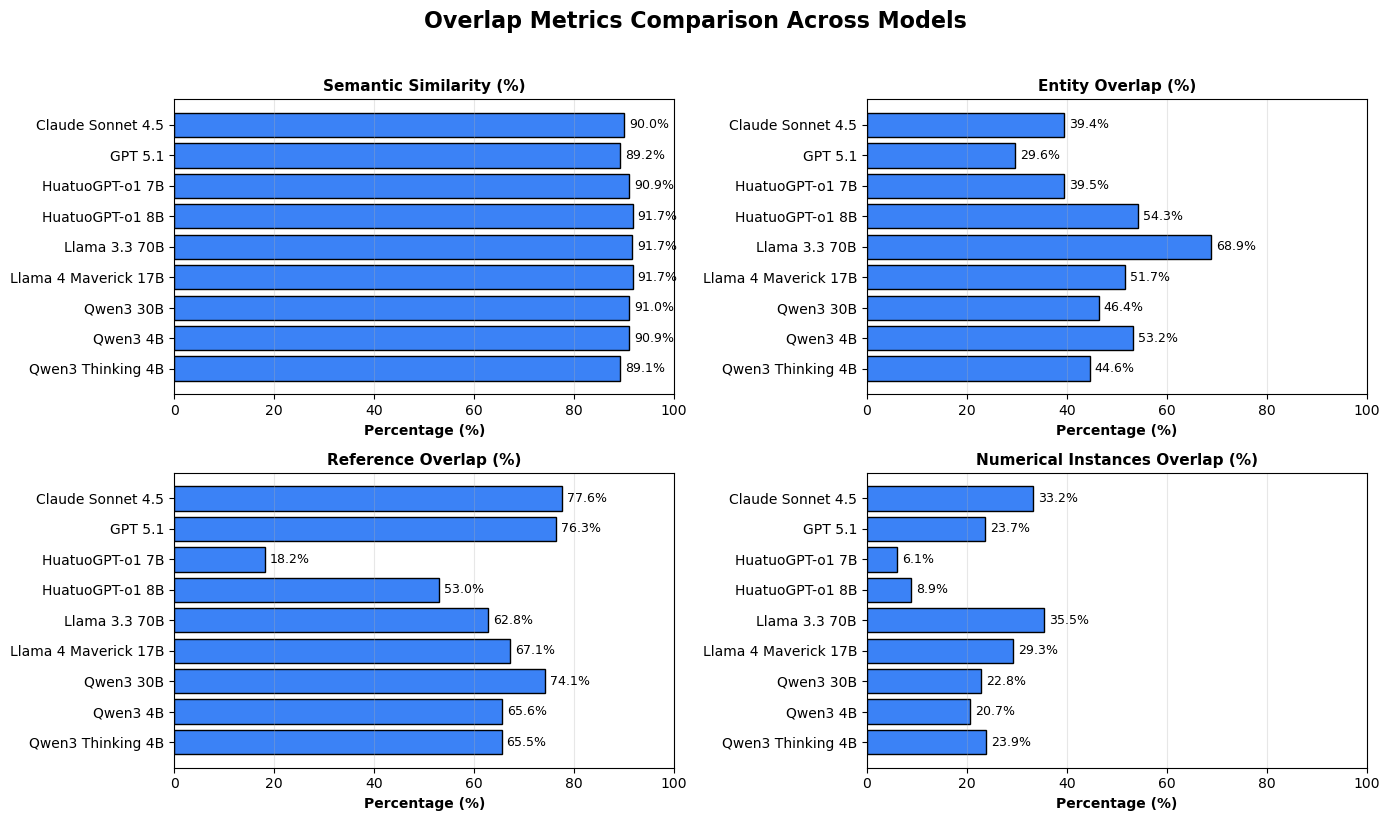


Readability (Flesch Reading Ease) Comparison...


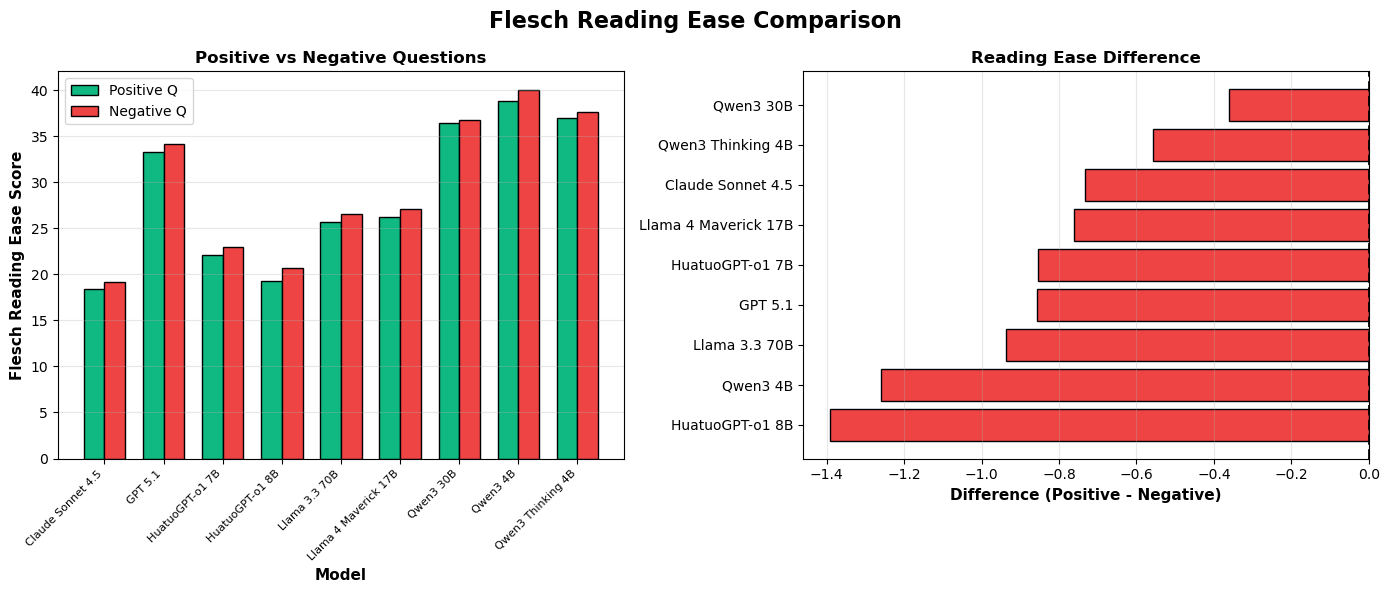

   - Box plots...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-3.3_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-4_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-30B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3_thinking-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-7B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-8B_eval_results.json: 5888


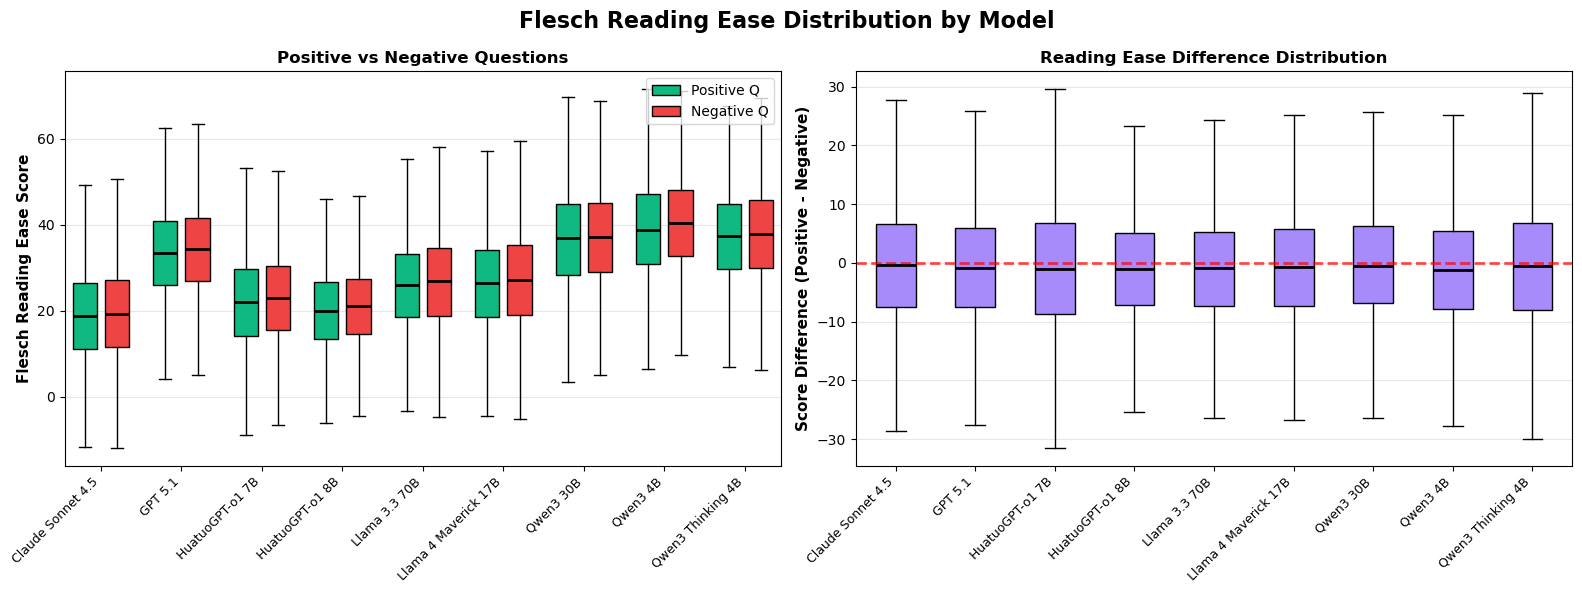


Medical Jargon Score Comparison...


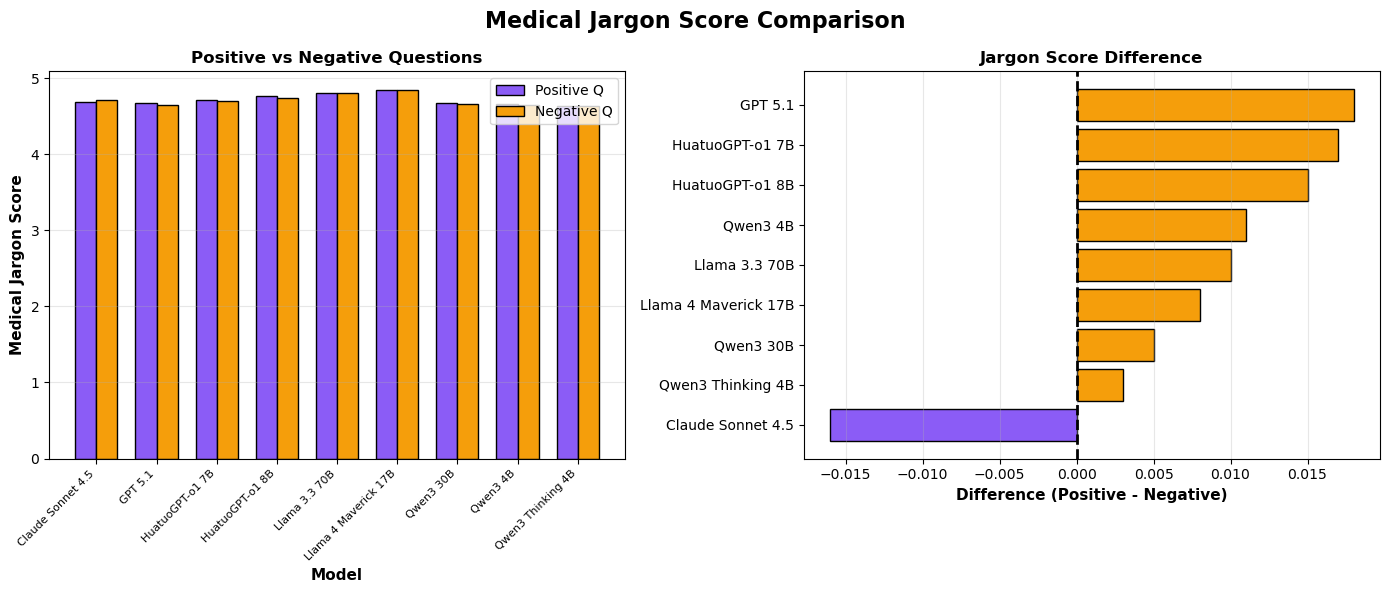

   - Box plots...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-3.3_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-4_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-30B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3_thinking-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-7B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-8B_eval_results.json: 5888


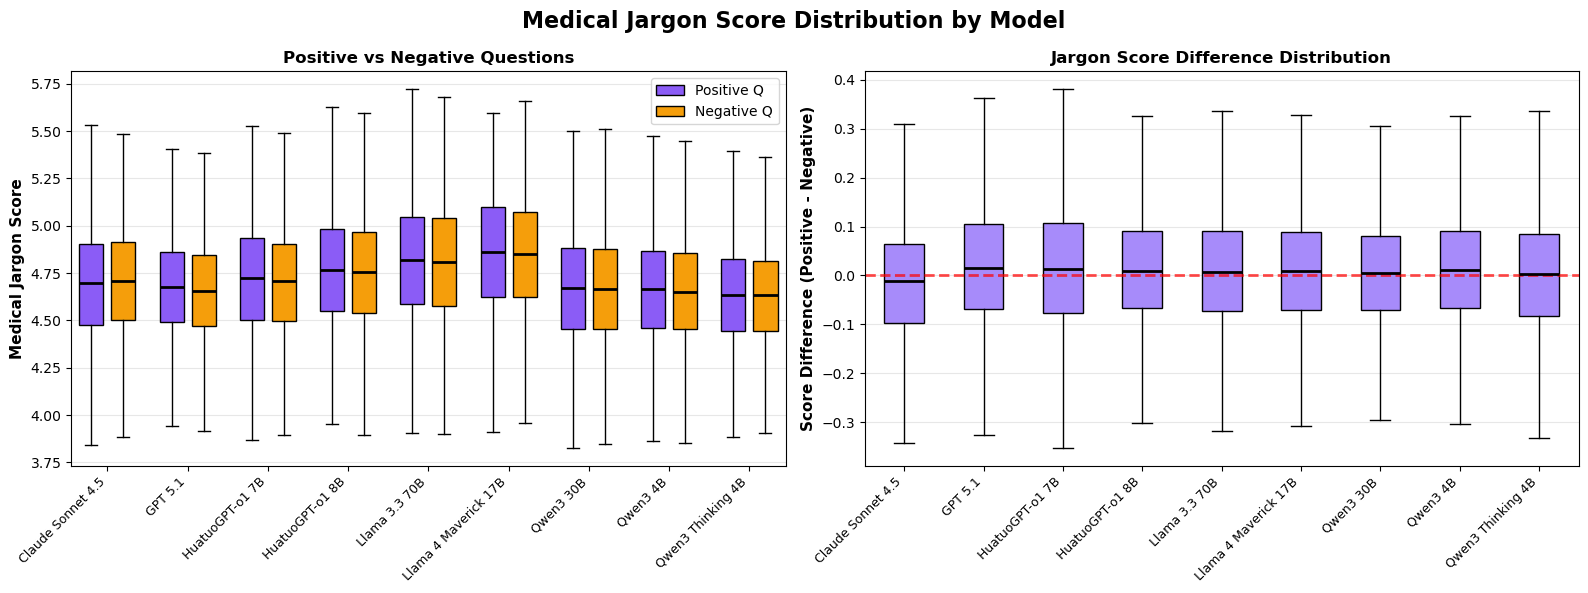


Response Length Comparison...


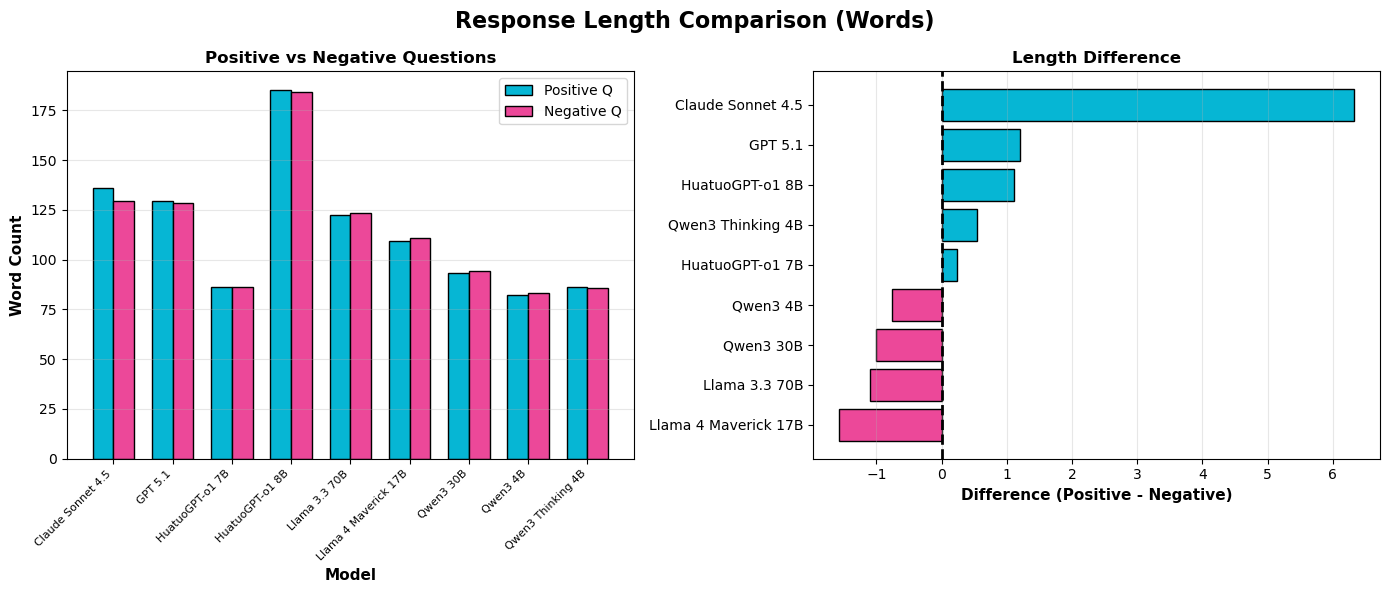

   - Box plots...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-3.3_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-4_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-30B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3_thinking-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-7B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-8B_eval_results.json: 5888


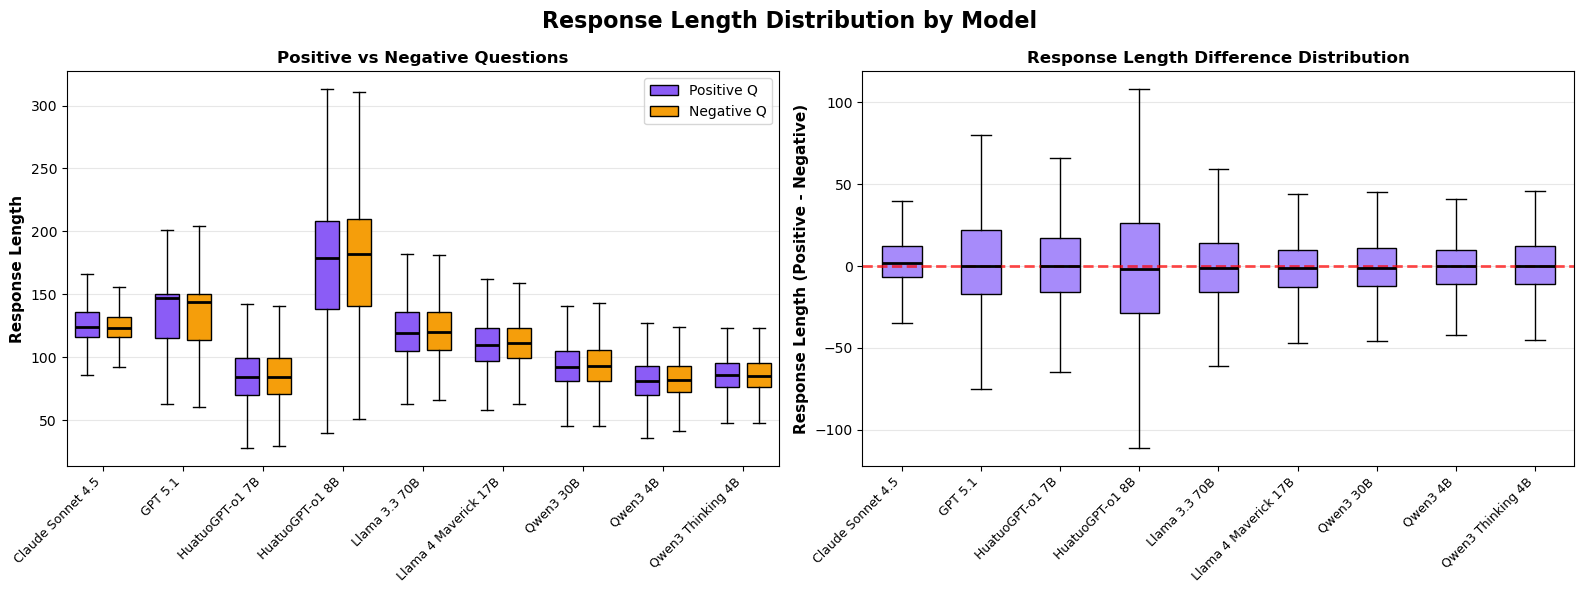


Hedge Count Comparison...


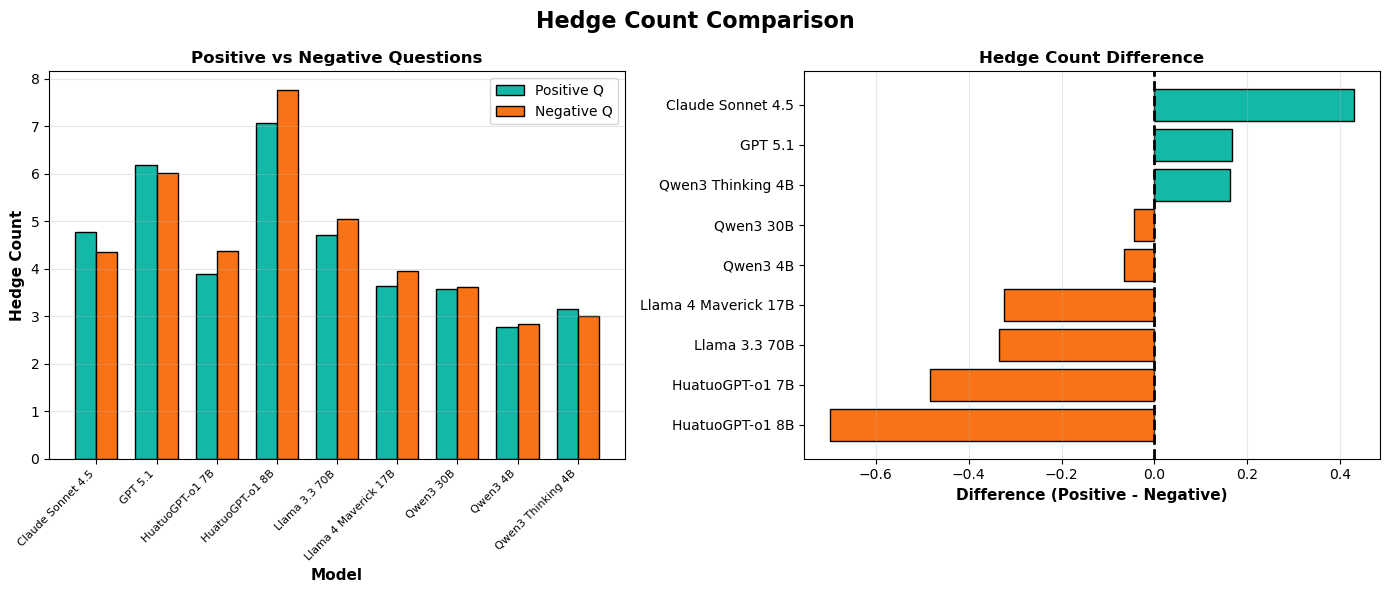

   - Box plots...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-3.3_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-4_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-30B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3_thinking-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-7B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-8B_eval_results.json: 5888


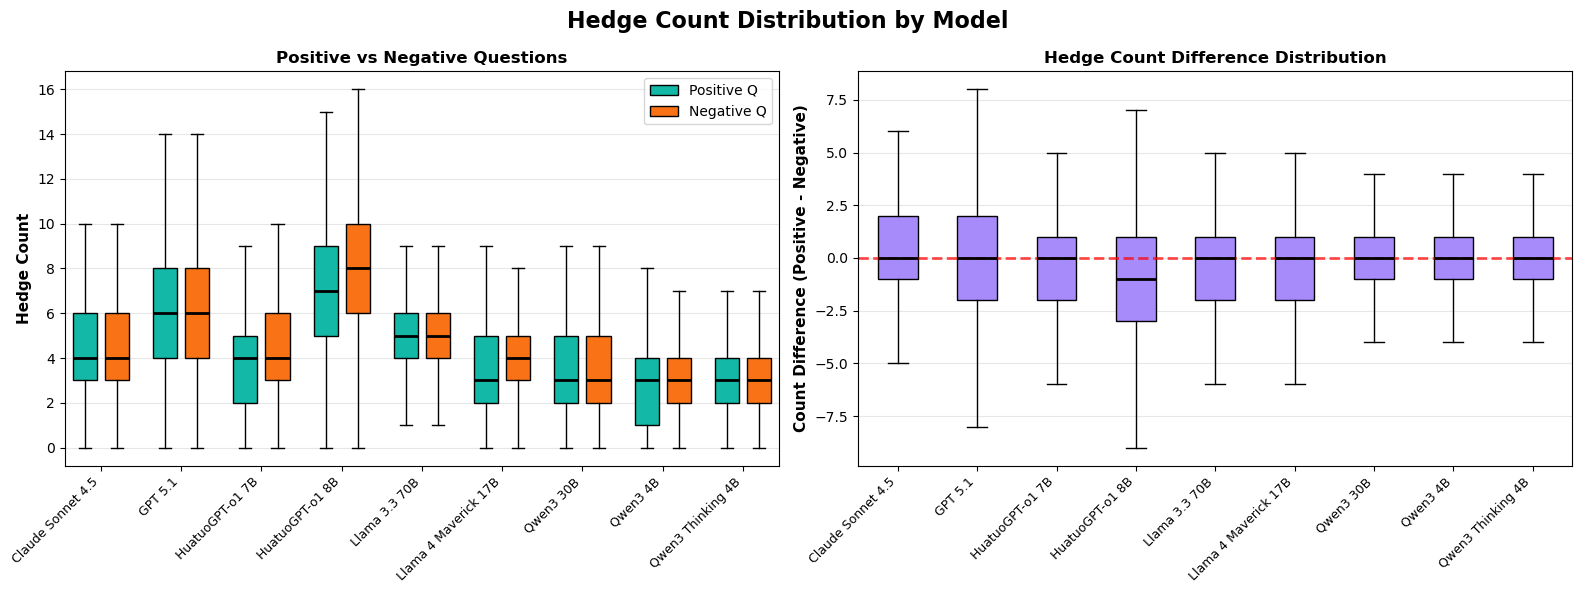


Evidence Direction Agreement Analysis...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-3.3_eval_results.json: 5888
Number of entries in outputs/evaluation/api_llama-4_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3-30B_eval_results.json: 5888
Number of entries in outputs/evaluation/qwen3_thinking-4B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-7B_eval_results.json: 5888
Number of entries in outputs/evaluation/huatuo-8B_eval_results.json: 5888


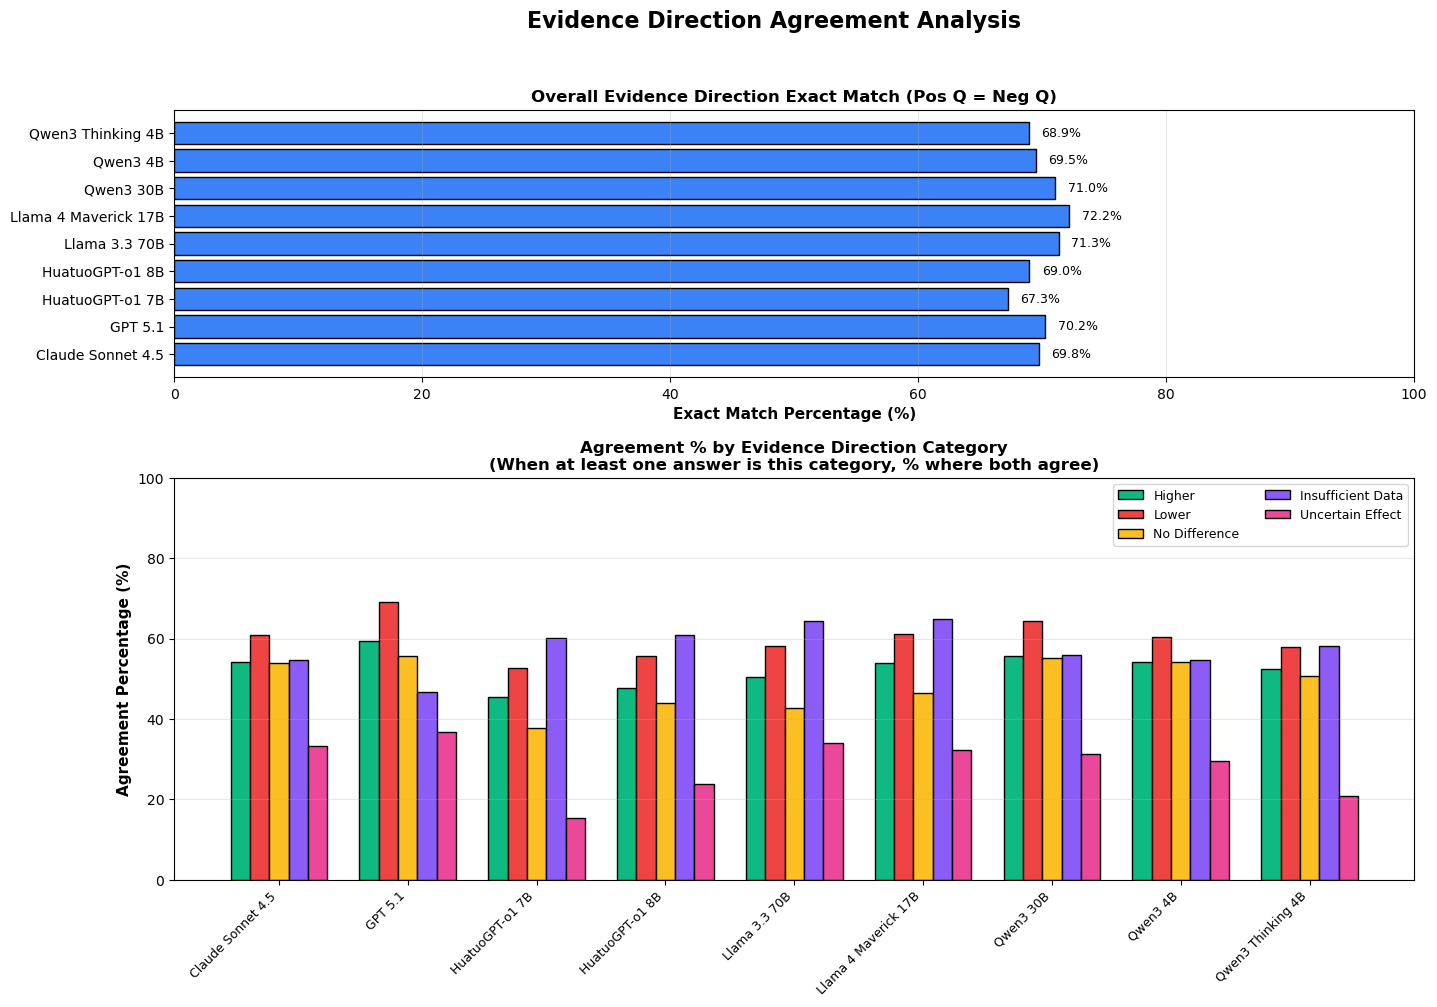


Radar Chart Comparison...


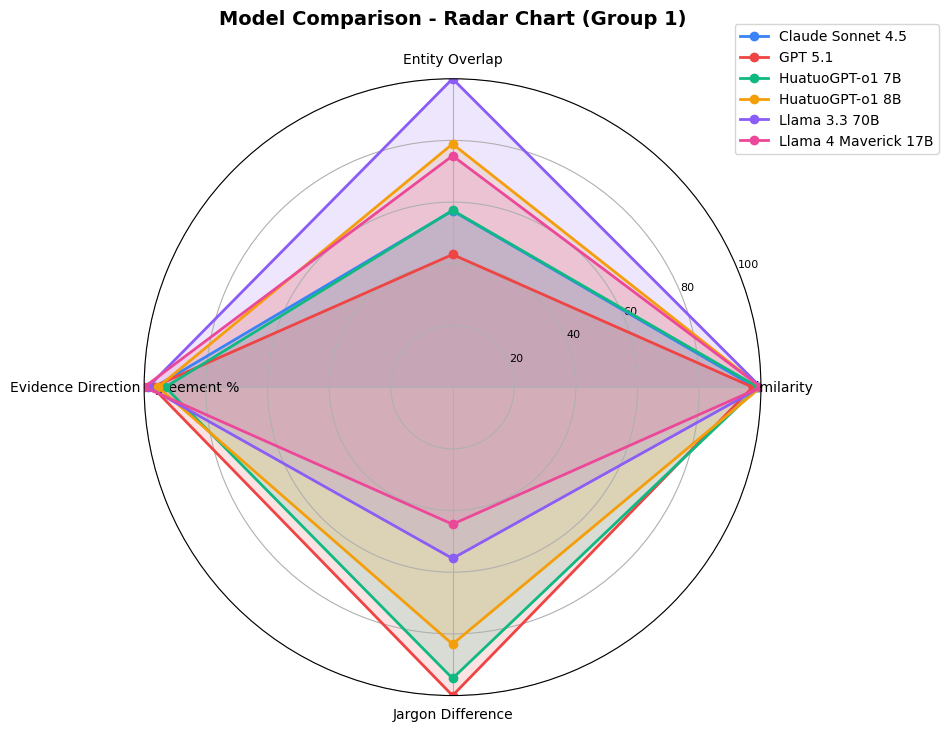

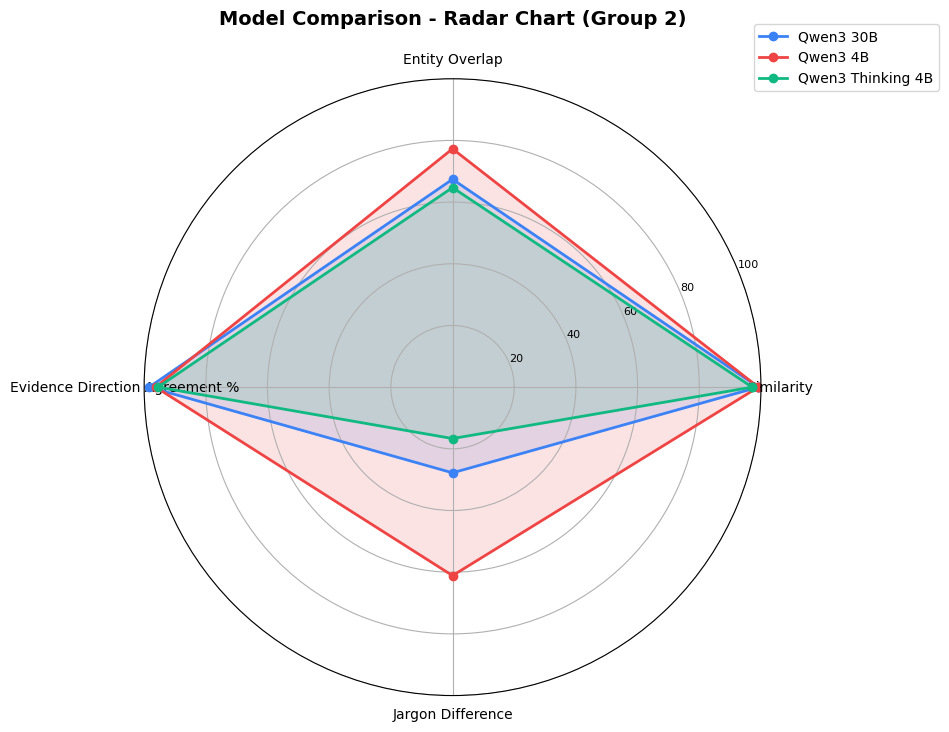


ALL VISUALIZATIONS COMPLETE


In [14]:
# ============================================================================
# MAIN EXECUTION: Load stats and generate visualizations
# ============================================================================

# Step 1: Load global statistics for all models
print("Loading global statistics for all models...")
all_model_stats = load_global_stats_for_all_models(model_names)

# Step 2: Convert to comparison DataFrame
# (Model labels and alphabetical sorting applied automatically)
print("\nPreparing comparison DataFrame...")
comparison_df = prepare_comparison_dataframe(all_model_stats)

# Display the comparison table
print("\n" + "=" * 80)
print("MODEL COMPARISON STATISTICS")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Step 3: Generate all visualizations
generate_all_visualizations(comparison_df)

In [15]:
# ============================================================================
# OPTIONAL: Use individual visualization functions
# ============================================================================
# You can also call individual visualization functions as needed:

# Individual visualizations:
# plot_overlap_metrics_comparison(comparison_df)
# plot_consistency_metrics_heatmap(comparison_df)
# plot_readability_comparison(comparison_df)
# plot_medical_jargon_comparison(comparison_df)
# plot_response_length_comparison(comparison_df)
# plot_hedges_comparison(comparison_df)
# plot_hedging_rating_analysis(comparison_df)
# plot_radar_chart_comparison(comparison_df)
# plot_all_differences_heatmap(comparison_df)

# Custom radar chart with specific metrics:
# custom_metrics = ['mean_similarity', 'mean_entity_overlap', 'mean_reference_overlap']
# plot_radar_chart_comparison(comparison_df, metrics_to_compare=custom_metrics)

In [16]:
# ============================================================================
# EXPORT UTILITIES: Save comparison data to files
# ============================================================================

def export_comparison_data(comparison_df: pd.DataFrame, 
                          all_model_stats: dict[str, dict],
                          output_dir: str = "outputs/analysis"):
    """
    Export comparison data to CSV and JSON files.
    
    Args:
        comparison_df: DataFrame with comparison statistics
        all_model_stats: Dictionary with full model statistics
        output_dir: Directory to save output files
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # Export comparison DataFrame to CSV
    csv_path = f"{output_dir}/model_comparison_summary.csv"
    comparison_df.to_csv(csv_path, index=False)
    print(f"✓ Exported comparison table to: {csv_path}")
    
    # Export full stats to JSON
    json_path = f"{output_dir}/all_model_stats.json"
    with open(json_path, 'w') as f:
        json.dump(all_model_stats, f, indent=2)
    print(f"✓ Exported full statistics to: {json_path}")
    
    # Create a summary report
    report_path = f"{output_dir}/model_comparison_report.txt"
    with open(report_path, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("MODEL COMPARISON REPORT\n")
        f.write("=" * 80 + "\n\n")
        
        f.write(f"Total Models Analyzed: {len(comparison_df)}\n")
        f.write(f"Models: {', '.join(comparison_df['model'].tolist())}\n\n")
        
        f.write("-" * 80 + "\n")
        f.write("KEY FINDINGS\n")
        f.write("-" * 80 + "\n\n")
        
        # Highest/lowest metrics
        f.write("OVERLAP METRICS:\n")
        f.write(f"  Highest Semantic Similarity: {comparison_df.loc[comparison_df['mean_similarity'].idxmax(), 'model']} ({comparison_df['mean_similarity'].max():.2f}%)\n")
        f.write(f"  Lowest Semantic Similarity: {comparison_df.loc[comparison_df['mean_similarity'].idxmin(), 'model']} ({comparison_df['mean_similarity'].min():.2f}%)\n")
        f.write(f"  Highest Entity Overlap: {comparison_df.loc[comparison_df['mean_entity_overlap'].idxmax(), 'model']} ({comparison_df['mean_entity_overlap'].max():.2f}%)\n\n")
        
        f.write("CONSISTENCY METRICS:\n")
        f.write(f"  Highest Evidence Direction Agreement: {comparison_df.loc[comparison_df['evidence_direction_agreement_pct'].idxmax(), 'model']} ({comparison_df['evidence_direction_agreement_pct'].max():.2f}%)\n")
        # f.write(f"  Highest Hedging Rating Match: {comparison_df.loc[comparison_df['hedging_rating_exact_match_pct'].idxmax(), 'model']} ({comparison_df['hedging_rating_exact_match_pct'].max():.2f}%)\n\n")
        
        f.write("READABILITY:\n")
        f.write(f"  Highest Flesch Reading Ease (Pos Q): {comparison_df.loc[comparison_df['flesch_pos_mean'].idxmax(), 'model']} ({comparison_df['flesch_pos_mean'].max():.2f})\n")
        f.write(f"  Largest Flesch Difference (Pos-Neg): {comparison_df.loc[comparison_df['flesch_difference'].abs().idxmax(), 'model']} ({comparison_df.loc[comparison_df['flesch_difference'].abs().idxmax(), 'flesch_difference']:.2f})\n\n")
        
        f.write("-" * 80 + "\n")
        f.write("FULL COMPARISON TABLE\n")
        f.write("-" * 80 + "\n\n")
        f.write(comparison_df.to_string(index=False))
        
    print(f"✓ Exported summary report to: {report_path}")

# Example usage (uncomment to export):
# export_comparison_data(comparison_df, all_model_stats)

In [17]:
# ============================================================================
# STATISTICAL ANALYSIS: Additional insights
# ============================================================================

def print_statistical_summary(comparison_df: pd.DataFrame):
    """
    Print statistical summary of key metrics across models.
    """
    print("\n" + "=" * 80)
    print("STATISTICAL SUMMARY ACROSS ALL MODELS")
    print("=" * 80)
    
    metrics = {
        'Semantic Similarity': 'mean_similarity',
        'Entity Overlap': 'mean_entity_overlap',
        'Reference Overlap': 'mean_reference_overlap',
        'Evidence Direction Agreement': 'evidence_direction_agreement_pct',
        # 'Hedging Rating Exact Match': 'hedging_rating_exact_match_pct',
        'Flesch Reading Ease Difference': 'flesch_difference',
        'Medical Jargon Difference': 'jargon_difference',
        'Response Length Difference': 'length_difference',
        'Hedge Count Difference': 'hedges_difference'
    }
    
    for name, col in metrics.items():
        values = comparison_df[col]
        print(f"\n{name}:")
        print(f"  Mean: {values.mean():.2f}")
        print(f"  Median: {values.median():.2f}")
        print(f"  Std Dev: {values.std():.2f}")
        print(f"  Min: {values.min():.2f} ({comparison_df.loc[values.idxmin(), 'model']})")
        print(f"  Max: {values.max():.2f} ({comparison_df.loc[values.idxmax(), 'model']})")
    
    print("\n" + "=" * 80)

# Uncomment to use:
# print_statistical_summary(comparison_df)

## Question Category Level


In [18]:
def calculate_category_level_stats(df: pd.DataFrame) -> dict:
    """
    Calculate evidence direction agreement and hedging rating exact match by question category.
    
    Args:
        df: Formatted dataframe from format_results_for_analysis
        
    Returns:
        Dictionary with category-level statistics
    """
    
    # Evidence Direction Agreement by Category
    valid_mask_evidence = ~(df["pos_q_evidence_direction"].isna() & df["neg_q_evidence_direction"].isna())
    df_valid_evidence = df[valid_mask_evidence].copy()
    
    evidence_by_category = {}
    for category in df_valid_evidence['category'].unique():
        cat_data = df_valid_evidence[df_valid_evidence['category'] == category]
        total = len(cat_data)
        agreements = ((cat_data["pos_q_evidence_direction"] == cat_data["neg_q_evidence_direction"]) & 
                     cat_data["pos_q_evidence_direction"].notna()).sum()
        agreement_pct = (agreements / total * 100) if total > 0 else 0
        
        evidence_by_category[category] = {
            'total': total,
            'agreements': agreements,
            'agreement_pct': round(agreement_pct, 2)
        }
    
    # # Hedging Rating Exact Match by Category
    # valid_mask_hedging = ~(df["pos_q_hedging_rating"].isna() & df["neg_q_hedging_rating"].isna())
    # df_valid_hedging = df[valid_mask_hedging].copy()
    
    # hedging_by_category = {}
    # for category in df_valid_hedging['category'].unique():
    #     cat_data = df_valid_hedging[df_valid_hedging['category'] == category]
    #     total = len(cat_data)
    #     exact_matches = (cat_data["pos_q_hedging_rating"] == cat_data["neg_q_hedging_rating"]).sum()
    #     exact_match_pct = (exact_matches / total * 100) if total > 0 else 0
        
    #     # Calculate mean difference
    #     cat_data = cat_data.copy()
    #     cat_data['rating_difference'] = cat_data["pos_q_hedging_rating"] - cat_data["neg_q_hedging_rating"]
    #     cat_data['absolute_difference'] = cat_data['rating_difference'].abs()
    #     mean_diff = cat_data['rating_difference'].mean()
    #     mean_abs_diff = cat_data['absolute_difference'].mean()
        
    #     hedging_by_category[category] = {
    #         'total': total,
    #         'exact_matches': exact_matches,
    #         'exact_match_pct': round(exact_match_pct, 2),
    #         'mean_difference': round(mean_diff, 3),
    #         'mean_abs_difference': round(mean_abs_diff, 3)
    #     }
    
    return {
        'evidence_direction_by_category': evidence_by_category,
        # 'hedging_rating_by_category': hedging_by_category
    }


def load_category_stats_for_all_models(model_names: list[str]) -> dict[str, dict]:
    """
    Load category-level statistics for all models.
    
    Args:
        model_names: List of model names to process
        
    Returns:
        Dictionary mapping model names to their category-level statistics
    """
    all_category_stats = {}
    
    for model_name in model_names:
        try:
            # Load data for this model
            data = load_analysis_results_for_model(model_name)
            
            # Format results
            df = format_results_for_analysis(data)
            
            # Calculate category-level stats
            cat_stats = calculate_category_level_stats(df)
            
            all_category_stats[model_name] = cat_stats
            print(f"✓ Loaded category stats for {model_name}")
            
        except Exception as e:
            print(f"✗ Error loading category stats for {model_name}: {str(e)}")
            # print error traceback for debugging
            traceback.print_exc()
            continue
    
    return all_category_stats

In [19]:
def prepare_category_comparison_dataframes(all_category_stats: dict[str, dict]) -> tuple:
    """
    Convert category statistics to DataFrames for visualization.
    
    Args:
        all_category_stats: Dictionary of category statistics for all models
        
    Returns:
        Tuple of (evidence_direction_df, hedging_rating_df)
    """
    # Evidence Direction Agreement by Category
    evidence_rows = []
    for model, stats in all_category_stats.items():
        for category, cat_data in stats['evidence_direction_by_category'].items():
            evidence_rows.append({
                'model': MODEL_LABELS.get(model, model),
                'category': category,
                'total': cat_data['total'],
                'agreements': cat_data['agreements'],
                'agreement_pct': cat_data['agreement_pct']
            })
    
    evidence_df = pd.DataFrame(evidence_rows)
    # Sort by model name for consistent ordering
    evidence_df = evidence_df.sort_values(['model', 'category']).reset_index(drop=True)
    
    # # Hedging Rating by Category
    # hedging_rows = []
    # for model, stats in all_category_stats.items():
    #     for category, cat_data in stats['hedging_rating_by_category'].items():
    #         hedging_rows.append({
    #             'model': MODEL_LABELS.get(model, model),
    #             'category': category,
    #             'total': cat_data['total'],
    #             'exact_matches': cat_data['exact_matches'],
    #             'exact_match_pct': cat_data['exact_match_pct'],
    #             'mean_difference': cat_data['mean_difference'],
    #             'mean_abs_difference': cat_data['mean_abs_difference']
    #         })
    
    # hedging_df = pd.DataFrame(hedging_rows)
    # # Sort by model name for consistent ordering
    # hedging_df = hedging_df.sort_values(['model', 'category']).reset_index(drop=True)
    
    # return evidence_df, hedging_df
    return evidence_df, None


def plot_evidence_direction_by_category(evidence_df: pd.DataFrame, figsize=(12, 6)):
    """
    Plot evidence direction agreement percentages by category across models.
    """
    # Get unique categories
    categories = sorted(evidence_df['category'].unique())

    # Grouped bar chart
    x = np.arange(len(categories))
    width = 0.8 / len(evidence_df['model'].unique())
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(evidence_df['model'].unique())))

    plt.figure(figsize=figsize)
    
    for i, model in enumerate(sorted(evidence_df['model'].unique())):
        model_data = evidence_df[evidence_df['model'] == model]
        model_data = model_data.sort_values('category')
        values = [model_data[model_data['category'] == cat]['agreement_pct'].values[0] 
                 if len(model_data[model_data['category'] == cat]) > 0 else 0 
                 for cat in categories]
        
        offset = (i - len(evidence_df['model'].unique())/2) * width + width/2
        plt.bar(x + offset, values, width, label=model, color=colors[i], edgecolor='black')
    
    plt.xlabel('Question Category', fontsize=14, fontweight='bold')
    plt.ylabel('Agreement Percentage (%)', fontsize=14, fontweight='bold')
    plt.title('Evidence Direction Agreement by Category and Model', fontsize=14, fontweight='bold')
    plt.xticks(x, categories, rotation=45, ha='right')
    plt.ylim(0, 100)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_hedging_rating_by_category(hedging_df: pd.DataFrame, figsize=(12, 6)):
    """
    Plot hedging rating exact match percentages by category across models.
    """
    # Get unique categories
    categories = sorted(hedging_df['category'].unique())
    
    plt.figure(figsize=figsize)
    
    # Grouped bar chart
    x = np.arange(len(categories))
    width = 0.8 / len(hedging_df['model'].unique())
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(hedging_df['model'].unique())))
    
    for i, model in enumerate(sorted(hedging_df['model'].unique())):
        model_data = hedging_df[hedging_df['model'] == model]
        model_data = model_data.sort_values('category')
        values = [model_data[model_data['category'] == cat]['exact_match_pct'].values[0] 
                 if len(model_data[model_data['category'] == cat]) > 0 else 0 
                 for cat in categories]
        
        offset = (i - len(hedging_df['model'].unique())/2) * width + width/2
        plt.bar(x + offset, values, width, label=model, color=colors[i], edgecolor='black')
    
    plt.xlabel('Question Category', fontsize=14, fontweight='bold')
    plt.ylabel('Exact Match Percentage (%)', fontsize=14, fontweight='bold')
    plt.title('Hedging Rating Exact Match by Category and Model', fontsize=14, fontweight='bold')
    plt.xticks(x, categories, rotation=45, ha='right')
    plt.ylim(0, 100)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [20]:
def generate_all_category_visualizations(evidence_df: pd.DataFrame, hedging_df: pd.DataFrame):
    """
    Generate all category-level visualization plots.
    
    Args:
        evidence_df: DataFrame with evidence direction stats by category
        hedging_df: DataFrame with hedging rating stats by category
    """
    print("=" * 60)
    print("GENERATING CATEGORY-LEVEL COMPARISON VISUALIZATIONS")
    print("=" * 60)
    
    print("\nEvidence Direction Agreement by Category...")
    plot_evidence_direction_by_category(evidence_df)
    
    # print("\nHedging Rating Exact Match by Category...")
    # plot_hedging_rating_by_category(hedging_df)
    
    print("\n" + "=" * 60)
    print("ALL CATEGORY VISUALIZATIONS COMPLETE")
    print("=" * 60)


def print_category_summary_tables(evidence_df: pd.DataFrame, hedging_df: pd.DataFrame):
    """
    Print summary tables for category-level statistics.
    """
    print("\n" + "=" * 80)
    print("EVIDENCE DIRECTION AGREEMENT BY CATEGORY")
    print("=" * 80)
    
    # Pivot and display
    evidence_pivot = evidence_df.pivot(index='model', columns='category', values='agreement_pct')
    print(evidence_pivot.to_string())
    
    # print("\n" + "=" * 80)
    # print("HEDGING RATING EXACT MATCH BY CATEGORY")
    # print("=" * 80)
    
    # # Pivot and display
    # hedging_pivot = hedging_df.pivot(index='model', columns='category', values='exact_match_pct')
    # print(hedging_pivot.to_string())
    
    # Summary statistics
    print("\n" + "=" * 80)
    print("SUMMARY STATISTICS")
    print("=" * 80)
    
    print("\nEvidence Direction Agreement:")
    print(f"  Overall Mean: {evidence_df['agreement_pct'].mean():.2f}%")
    print(f"  Overall Std Dev: {evidence_df['agreement_pct'].std():.2f}%")
    print(f"  Best Model (Avg): {evidence_df.groupby('model')['agreement_pct'].mean().idxmax()} ({evidence_df.groupby('model')['agreement_pct'].mean().max():.2f}%)")
    print(f"  Most Consistent Model (Lowest Std): {evidence_df.groupby('model')['agreement_pct'].std().idxmin()} ({evidence_df.groupby('model')['agreement_pct'].std().min():.2f}%)")
    
    # print("\nHedging Rating Exact Match:")
    # print(f"  Overall Mean: {hedging_df['exact_match_pct'].mean():.2f}%")
    # print(f"  Overall Std Dev: {hedging_df['exact_match_pct'].std():.2f}%")
    # print(f"  Best Model (Avg): {hedging_df.groupby('model')['exact_match_pct'].mean().idxmax()} ({hedging_df.groupby('model')['exact_match_pct'].mean().max():.2f}%)")
    # print(f"  Most Consistent Model (Lowest Std): {hedging_df.groupby('model')['exact_match_pct'].std().idxmin()} ({hedging_df.groupby('model')['exact_match_pct'].std().min():.2f}%)")
    
    print("\n" + "=" * 80)

Loading category-level statistics for all models...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
✓ Loaded category stats for gpt-5.1
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
✓ Loaded category stats for claude_4.5_sonnet
Number of entries in outputs/evaluation/api_llama-3.3_eval_results.json: 5888
✓ Loaded category stats for api_llama-3.3
Number of entries in outputs/evaluation/api_llama-4_eval_results.json: 5888
✓ Loaded category stats for api_llama-4
Number of entries in outputs/evaluation/qwen3-4B_eval_results.json: 5888
✓ Loaded category stats for qwen3-4B
Number of entries in outputs/evaluation/qwen3-30B_eval_results.json: 5888
✓ Loaded category stats for qwen3-30B
Number of entries in outputs/evaluation/qwen3_thinking-4B_eval_results.json: 5888
✓ Loaded category stats for qwen3_thinking-4B
Number of entries in outputs/evaluation/huatuo-7B_eval_results.json: 5888
✓ Loaded category stats for huatuo-7B
Number of entr

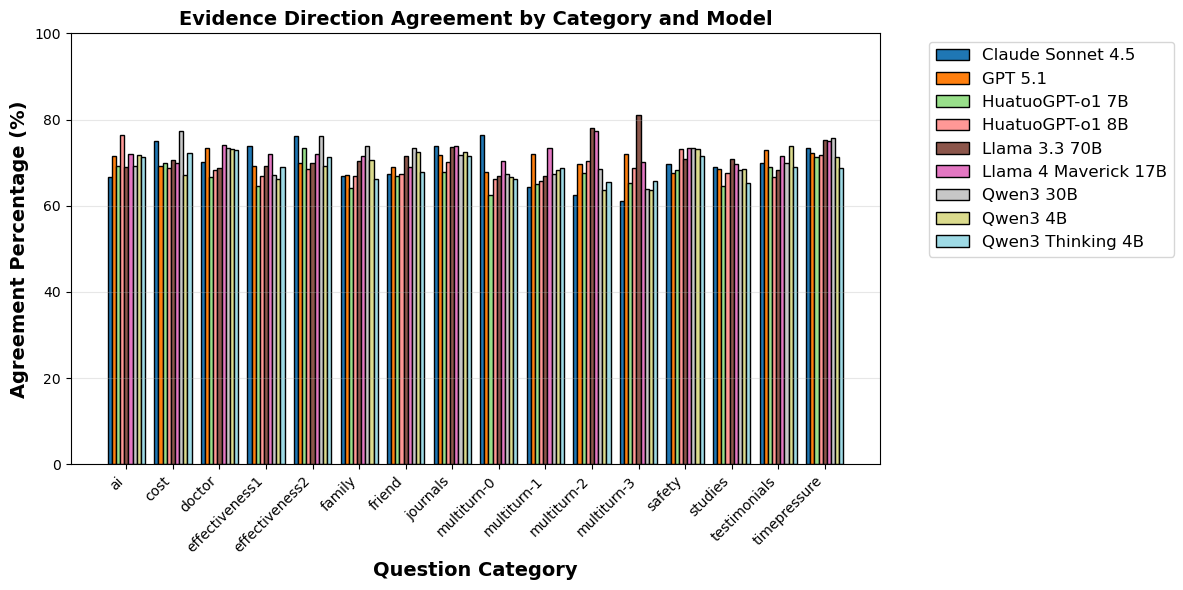


ALL CATEGORY VISUALIZATIONS COMPLETE


In [21]:
# ============================================================================
# CATEGORY-LEVEL ANALYSIS EXECUTION
# ============================================================================

# Load category-level statistics for all models
print("Loading category-level statistics for all models...")
all_category_stats = load_category_stats_for_all_models(model_names)

# Prepare DataFrames for visualization
print("\nPreparing category comparison DataFrames...")
evidence_by_category_df, hedging_by_category_df = prepare_category_comparison_dataframes(all_category_stats)

# Print summary tables
print_category_summary_tables(evidence_by_category_df, hedging_by_category_df)

# Generate all category visualizations
generate_all_category_visualizations(evidence_by_category_df, hedging_by_category_df)

## Condition Category Level

In [22]:
def calculate_condition_category_level_stats(df: pd.DataFrame) -> dict:
    """
    Calculate evidence direction agreement and hedging rating exact match by condition category.
    
    Args:
        df: Formatted dataframe from format_results_for_analysis
        
    Returns:
        Dictionary with condition-category-level statistics
    """
    
    # Evidence Direction Agreement by Condition Category
    valid_mask_evidence = ~(df["pos_q_evidence_direction"].isna() & df["neg_q_evidence_direction"].isna())
    df_valid_evidence = df[valid_mask_evidence].copy()
    
    evidence_by_condition = {}
    for condition in df_valid_evidence['condition_category'].unique():
        cond_data = df_valid_evidence[df_valid_evidence['condition_category'] == condition]
        total = len(cond_data)
        agreements = ((cond_data["pos_q_evidence_direction"] == cond_data["neg_q_evidence_direction"]) & 
                     cond_data["pos_q_evidence_direction"].notna()).sum()
        agreement_pct = (agreements / total * 100) if total > 0 else 0
        
        evidence_by_condition[condition] = {
            'total': total,
            'agreements': agreements,
            'agreement_pct': round(agreement_pct, 2)
        }
    
    # # Hedging Rating Exact Match by Condition Category
    # valid_mask_hedging = ~(df["pos_q_hedging_rating"].isna() & df["neg_q_hedging_rating"].isna())
    # df_valid_hedging = df[valid_mask_hedging].copy()
    
    # hedging_by_condition = {}
    # for condition in df_valid_hedging['condition_category'].unique():
    #     cond_data = df_valid_hedging[df_valid_hedging['condition_category'] == condition]
    #     total = len(cond_data)
    #     exact_matches = (cond_data["pos_q_hedging_rating"] == cond_data["neg_q_hedging_rating"]).sum()
    #     exact_match_pct = (exact_matches / total * 100) if total > 0 else 0
        
    #     # Calculate mean difference
    #     cond_data = cond_data.copy()
    #     cond_data['rating_difference'] = cond_data["pos_q_hedging_rating"] - cond_data["neg_q_hedging_rating"]
    #     cond_data['absolute_difference'] = cond_data['rating_difference'].abs()
    #     mean_diff = cond_data['rating_difference'].mean()
    #     mean_abs_diff = cond_data['absolute_difference'].mean()
        
    #     hedging_by_condition[condition] = {
    #         'total': total,
    #         'exact_matches': exact_matches,
    #         'exact_match_pct': round(exact_match_pct, 2),
    #         'mean_difference': round(mean_diff, 3),
    #         'mean_abs_difference': round(mean_abs_diff, 3)
    #     }
    
    return {
        'evidence_direction_by_condition': evidence_by_condition,
        # 'hedging_rating_by_condition': hedging_by_condition
    }


def load_condition_category_stats_for_all_models(model_names: list[str]) -> dict[str, dict]:
    """
    Load condition-category-level statistics for all models.
    
    Args:
        model_names: List of model names to process
        
    Returns:
        Dictionary mapping model names to their condition-category-level statistics
    """
    all_condition_stats = {}
    
    for model_name in model_names:
        data = load_analysis_results_for_model(model_name)
        df = format_results_for_analysis(data)
        cond_stats = calculate_condition_category_level_stats(df)
        all_condition_stats[model_name] = cond_stats
        print(f"✓ Loaded condition category stats for {model_name}")
    
    return all_condition_stats

In [23]:
def prepare_condition_category_comparison_dataframes(all_condition_stats: dict[str, dict]) -> tuple:
    """
    Convert condition category statistics to DataFrames for visualization.
    
    Args:
        all_condition_stats: Dictionary of condition category statistics for all models
        
    Returns:
        Tuple of (evidence_direction_df, hedging_rating_df)
    """
    # Evidence Direction Agreement by Condition Category
    evidence_rows = []
    for model, stats in all_condition_stats.items():
        for condition, cond_data in stats['evidence_direction_by_condition'].items():
            evidence_rows.append({
                'model': MODEL_LABELS.get(model, model),
                'condition_category': condition,
                'total': cond_data['total'],
                'agreements': cond_data['agreements'],
                'agreement_pct': cond_data['agreement_pct']
            })
    
    evidence_df = pd.DataFrame(evidence_rows)
    evidence_df = evidence_df.sort_values(['model', 'condition_category']).reset_index(drop=True)
    
    # # Hedging Rating by Condition Category
    # hedging_rows = []
    # for model, stats in all_condition_stats.items():
    #     for condition, cond_data in stats['hedging_rating_by_condition'].items():
    #         hedging_rows.append({
    #             'model': MODEL_LABELS.get(model, model),
    #             'condition_category': condition,
    #             'total': cond_data['total'],
    #             'exact_matches': cond_data['exact_matches'],
    #             'exact_match_pct': cond_data['exact_match_pct'],
    #             'mean_difference': cond_data['mean_difference'],
    #             'mean_abs_difference': cond_data['mean_abs_difference']
    #         })
    
    # hedging_df = pd.DataFrame(hedging_rows)
    # hedging_df = hedging_df.sort_values(['model', 'condition_category']).reset_index(drop=True)
    
    # return evidence_df, hedging_df
    return evidence_df, None


def plot_evidence_direction_by_condition_category(evidence_df: pd.DataFrame, figsize=(18, 8)):
    """
    Plot evidence direction agreement percentages by condition category across models.
    """
    categories = sorted(evidence_df['condition_category'].unique())

    x = np.arange(len(categories))
    models = sorted(evidence_df['model'].unique())
    width = 0.8 / len(models)
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(models)))

    plt.figure(figsize=figsize)
    
    for i, model in enumerate(models):
        model_data = evidence_df[evidence_df['model'] == model]
        values = [model_data[model_data['condition_category'] == cat]['agreement_pct'].values[0] 
                 if len(model_data[model_data['condition_category'] == cat]) > 0 else 0 
                 for cat in categories]
        
        offset = (i - len(models)/2) * width + width/2
        plt.bar(x + offset, values, width, label=model, color=colors[i], edgecolor='black')
    
    plt.xlabel('Condition Category', fontsize=14, fontweight='bold')
    plt.ylabel('Agreement Percentage (%)', fontsize=14, fontweight='bold')
    plt.title('Evidence Direction Agreement by Condition Category and Model', fontsize=14, fontweight='bold')
    plt.xticks(x, categories, rotation=45, ha='right', fontsize=9)
    plt.ylim(0, 100)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_hedging_rating_by_condition_category(hedging_df: pd.DataFrame, figsize=(18, 8)):
    """
    Plot hedging rating exact match percentages by condition category across models.
    """
    categories = sorted(hedging_df['condition_category'].unique())
    
    plt.figure(figsize=figsize)
    
    x = np.arange(len(categories))
    models = sorted(hedging_df['model'].unique())
    width = 0.8 / len(models)
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(models)))
    
    for i, model in enumerate(models):
        model_data = hedging_df[hedging_df['model'] == model]
        values = [model_data[model_data['condition_category'] == cat]['exact_match_pct'].values[0] 
                 if len(model_data[model_data['condition_category'] == cat]) > 0 else 0 
                 for cat in categories]
        
        offset = (i - len(models)/2) * width + width/2
        plt.bar(x + offset, values, width, label=model, color=colors[i], edgecolor='black')
    
    plt.xlabel('Condition Category', fontsize=14, fontweight='bold')
    plt.ylabel('Exact Match Percentage (%)', fontsize=14, fontweight='bold')
    plt.title('Hedging Rating Exact Match by Condition Category and Model', fontsize=14, fontweight='bold')
    plt.xticks(x, categories, rotation=45, ha='right', fontsize=9)
    plt.ylim(0, 100)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [24]:
def generate_all_condition_category_visualizations(evidence_df: pd.DataFrame, hedging_df: pd.DataFrame):
    """
    Generate all condition-category-level visualization plots.
    
    Args:
        evidence_df: DataFrame with evidence direction stats by condition category
        hedging_df: DataFrame with hedging rating stats by condition category
    """
    print("=" * 60)
    print("GENERATING CONDITION-CATEGORY-LEVEL COMPARISON VISUALIZATIONS")
    print("=" * 60)
    
    print("\nEvidence Direction Agreement by Condition Category...")
    plot_evidence_direction_by_condition_category(evidence_df)
    
    # print("\nHedging Rating Exact Match by Condition Category...")
    # plot_hedging_rating_by_condition_category(hedging_df)
    
    print("\n" + "=" * 60)
    print("ALL CONDITION CATEGORY VISUALIZATIONS COMPLETE")
    print("=" * 60)


def print_condition_category_summary_tables(evidence_df: pd.DataFrame, hedging_df: pd.DataFrame):
    """
    Print summary tables for condition-category-level statistics.
    """
    print("\n" + "=" * 80)
    print("EVIDENCE DIRECTION AGREEMENT BY CONDITION CATEGORY")
    print("=" * 80)
    
    evidence_pivot = evidence_df.pivot(index='model', columns='condition_category', values='agreement_pct')
    print(evidence_pivot.to_string())
    
    # print("\n" + "=" * 80)
    # print("HEDGING RATING EXACT MATCH BY CONDITION CATEGORY")
    # print("=" * 80)
    
    # hedging_pivot = hedging_df.pivot(index='model', columns='condition_category', values='exact_match_pct')
    # print(hedging_pivot.to_string())
    
    # Summary statistics
    print("\n" + "=" * 80)
    print("SUMMARY STATISTICS")
    print("=" * 80)
    
    print("\nEvidence Direction Agreement:")
    print(f"  Overall Mean: {evidence_df['agreement_pct'].mean():.2f}%")
    print(f"  Overall Std Dev: {evidence_df['agreement_pct'].std():.2f}%")
    print(f"  Best Model (Avg): {evidence_df.groupby('model')['agreement_pct'].mean().idxmax()} ({evidence_df.groupby('model')['agreement_pct'].mean().max():.2f}%)")
    print(f"  Most Consistent Model (Lowest Std): {evidence_df.groupby('model')['agreement_pct'].std().idxmin()} ({evidence_df.groupby('model')['agreement_pct'].std().min():.2f}%)")
    print(f"  Highest Condition Category (Avg): {evidence_df.groupby('condition_category')['agreement_pct'].mean().idxmax()} ({evidence_df.groupby('condition_category')['agreement_pct'].mean().max():.2f}%)")
    print(f"  Lowest Condition Category (Avg): {evidence_df.groupby('condition_category')['agreement_pct'].mean().idxmin()} ({evidence_df.groupby('condition_category')['agreement_pct'].mean().min():.2f}%)")
    
    # print("\nHedging Rating Exact Match:")
    # print(f"  Overall Mean: {hedging_df['exact_match_pct'].mean():.2f}%")
    # print(f"  Overall Std Dev: {hedging_df['exact_match_pct'].std():.2f}%")
    # print(f"  Best Model (Avg): {hedging_df.groupby('model')['exact_match_pct'].mean().idxmax()} ({hedging_df.groupby('model')['exact_match_pct'].mean().max():.2f}%)")
    # print(f"  Most Consistent Model (Lowest Std): {hedging_df.groupby('model')['exact_match_pct'].std().idxmin()} ({hedging_df.groupby('model')['exact_match_pct'].std().min():.2f}%)")
    # print(f"  Highest Condition Category (Avg): {hedging_df.groupby('condition_category')['exact_match_pct'].mean().idxmax()} ({hedging_df.groupby('condition_category')['exact_match_pct'].mean().max():.2f}%)")
    # print(f"  Lowest Condition Category (Avg): {hedging_df.groupby('condition_category')['exact_match_pct'].mean().idxmin()} ({hedging_df.groupby('condition_category')['exact_match_pct'].mean().min():.2f}%)")
    
    print("\n" + "=" * 80)

Loading condition-category-level statistics for all models...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
✓ Loaded condition category stats for gpt-5.1
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
✓ Loaded condition category stats for claude_4.5_sonnet
Number of entries in outputs/evaluation/api_llama-3.3_eval_results.json: 5888
✓ Loaded condition category stats for api_llama-3.3
Number of entries in outputs/evaluation/api_llama-4_eval_results.json: 5888
✓ Loaded condition category stats for api_llama-4
Number of entries in outputs/evaluation/qwen3-4B_eval_results.json: 5888
✓ Loaded condition category stats for qwen3-4B
Number of entries in outputs/evaluation/qwen3-30B_eval_results.json: 5888
✓ Loaded condition category stats for qwen3-30B
Number of entries in outputs/evaluation/qwen3_thinking-4B_eval_results.json: 5888
✓ Loaded condition category stats for qwen3_thinking-4B
Number of entries in outputs/evaluation/huatuo

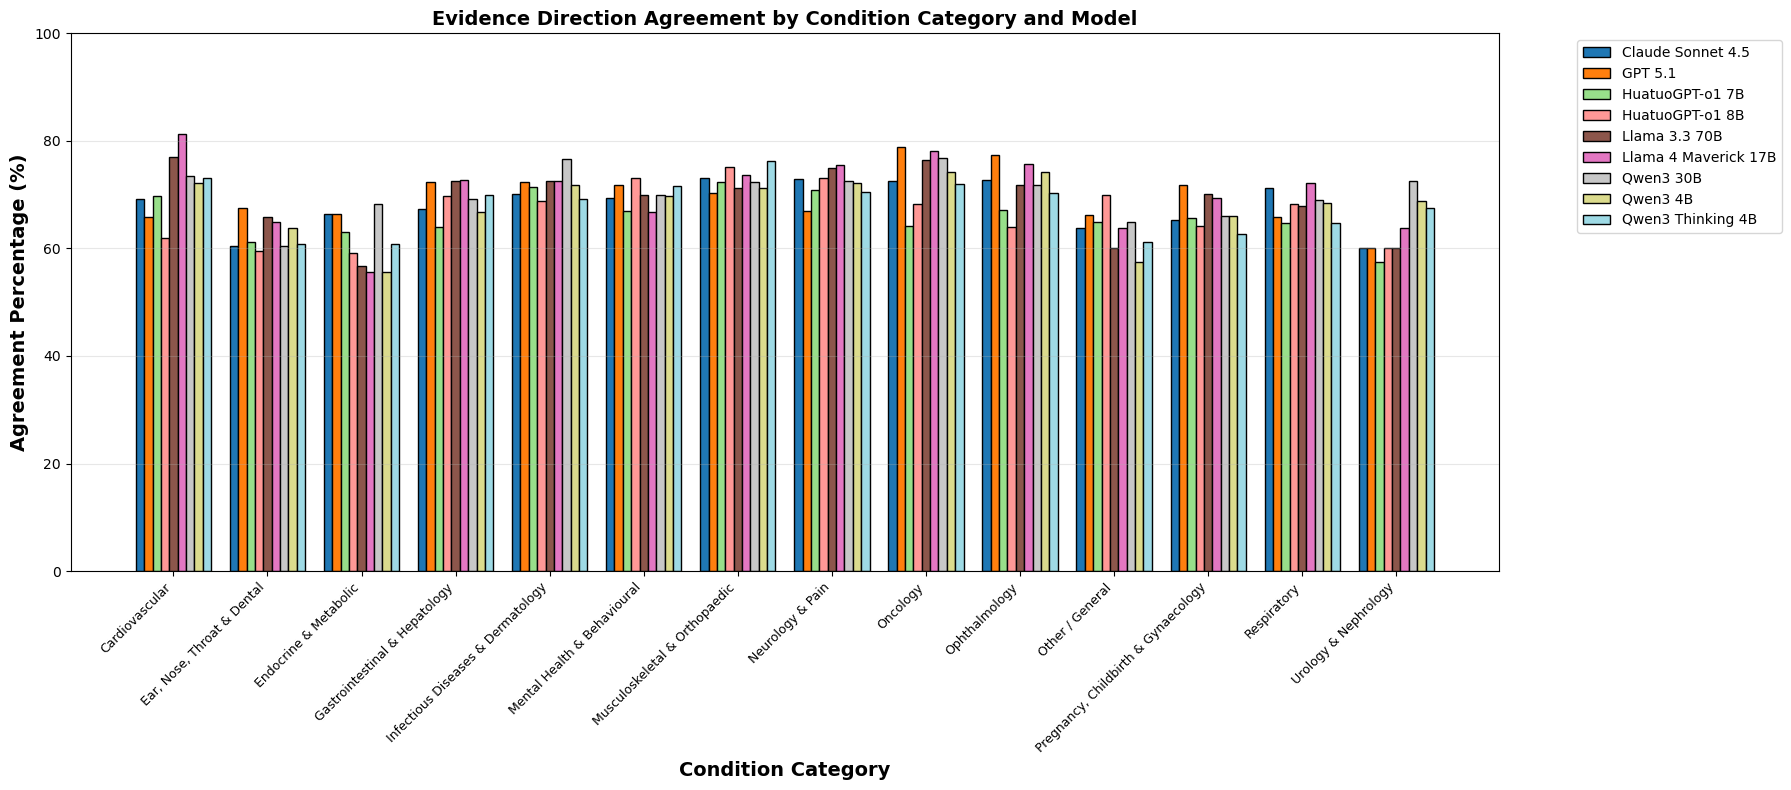


ALL CONDITION CATEGORY VISUALIZATIONS COMPLETE


In [25]:
# ============================================================================
# CONDITION-CATEGORY-LEVEL ANALYSIS EXECUTION
# ============================================================================

# Load condition-category-level statistics for all models
print("Loading condition-category-level statistics for all models...")
all_condition_category_stats = load_condition_category_stats_for_all_models(model_names)

# Prepare DataFrames for visualization
print("\nPreparing condition category comparison DataFrames...")
evidence_by_condition_df, hedging_by_condition_df = prepare_condition_category_comparison_dataframes(all_condition_category_stats)

# Print summary tables
print_condition_category_summary_tables(evidence_by_condition_df, hedging_by_condition_df)

# Generate all condition category visualizations
generate_all_condition_category_visualizations(evidence_by_condition_df, hedging_by_condition_df)

## By Year of Review

In [ ]:
def load_year_mapping() -> dict:
    """Load a mapping from ReviewID to publication year from cochrane_review_data.jsonl."""
    data = load_jsonl_file("../data/cochrane_review_data.jsonl")
    year_map = {}
    for entry in data:
        year_map[entry["ReviewID"]] = entry["Year"]
    return year_map


def calculate_year_level_agreement(model_name: str, year_map: dict) -> pd.DataFrame:
    """
    For a single model, compute evidence direction agreement grouped by publication year.

    Args:
        model_name: Model identifier string
        year_map: Mapping from ReviewID to publication year

    Returns:
        DataFrame with columns [year, agreement_pct, n, model]
    """
    data = load_analysis_results_for_model(model_name)
    df = format_results_for_analysis(data)

    # Add year column
    df["year"] = df["review_id"].map(year_map)
    df = df.dropna(subset=["year"])
    df["year"] = df["year"].astype(int)

    # Filter to rows where at least one evidence direction is non-null
    valid_mask = ~(df["pos_q_evidence_direction"].isna() & df["neg_q_evidence_direction"].isna())
    df = df[valid_mask].copy()

    rows = []
    for year, group in df.groupby("year"):
        total = len(group)
        agreements = (
            (group["pos_q_evidence_direction"] == group["neg_q_evidence_direction"])
            & group["pos_q_evidence_direction"].notna()
        ).sum()
        agreement_pct = (agreements / total * 100) if total > 0 else 0
        rows.append({"year": year, "agreement_pct": round(agreement_pct, 2), "n": total})

    result = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
    result["model"] = MODEL_LABELS.get(model_name, model_name)
    return result


def load_year_level_stats_for_all_models(model_names: list[str]) -> pd.DataFrame:
    """
    Load year-level evidence direction agreement for all models.

    Returns:
        Long-format DataFrame with columns [year, agreement_pct, n, model]
    """
    year_map = load_year_mapping()
    all_dfs = []
    for model_name in model_names:
        try:
            df = calculate_year_level_agreement(model_name, year_map)
            all_dfs.append(df)
            print(f"✓ Loaded year stats for {model_name}")
        except Exception as e:
            print(f"✗ Error loading {model_name}: {e}")
            traceback.print_exc()
    return pd.concat(all_dfs, ignore_index=True)


def plot_evidence_direction_agreement_by_year(year_df: pd.DataFrame, figsize=(14, 7)):
    """
    Line plot of average evidence direction agreement (%) per publication year, one line per model.
    """
    fig, ax = plt.subplots(figsize=figsize)

    models = sorted(year_df["model"].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

    for model, color in zip(models, colors):
        model_data = year_df[year_df["model"] == model].sort_values("year")
        ax.plot(
            model_data["year"],
            model_data["agreement_pct"],
            marker="o",
            markersize=4,
            linewidth=1.8,
            label=model,
            color=color,
        )

    ax.set_xlabel("Publication Year of Cochrane Review", fontsize=12, fontweight="bold")
    ax.set_ylabel("Evidence Direction Agreement (%)", fontsize=12, fontweight="bold")
    ax.set_title(
        "Average Evidence Direction Agreement by Publication Year",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_ylim(0, 100)
    ax.grid(axis="both", alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()


Loading year-level evidence direction agreement for all models...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
                      full_id review_id        category condition_category  \
0     CD002818_effectiveness1  CD002818  effectiveness1   Neurology & Pain   
1     CD002818_effectiveness2  CD002818  effectiveness2   Neurology & Pain   
2             CD002818_safety  CD002818          safety   Neurology & Pain   
3            CD002818_studies  CD002818         studies   Neurology & Pain   
4       CD002818_timepressure  CD002818    timepressure   Neurology & Pain   
...                       ...       ...             ...                ...   
5883          CD004979_doctor  CD004979          doctor        Respiratory   
5884     CD004979_multiturn-0  CD004979     multiturn-0        Respiratory   
5885     CD004979_multiturn-1  CD004979     multiturn-1        Respiratory   
5886     CD004979_multiturn-2  CD004979     multiturn-2        Respiratory   
5887

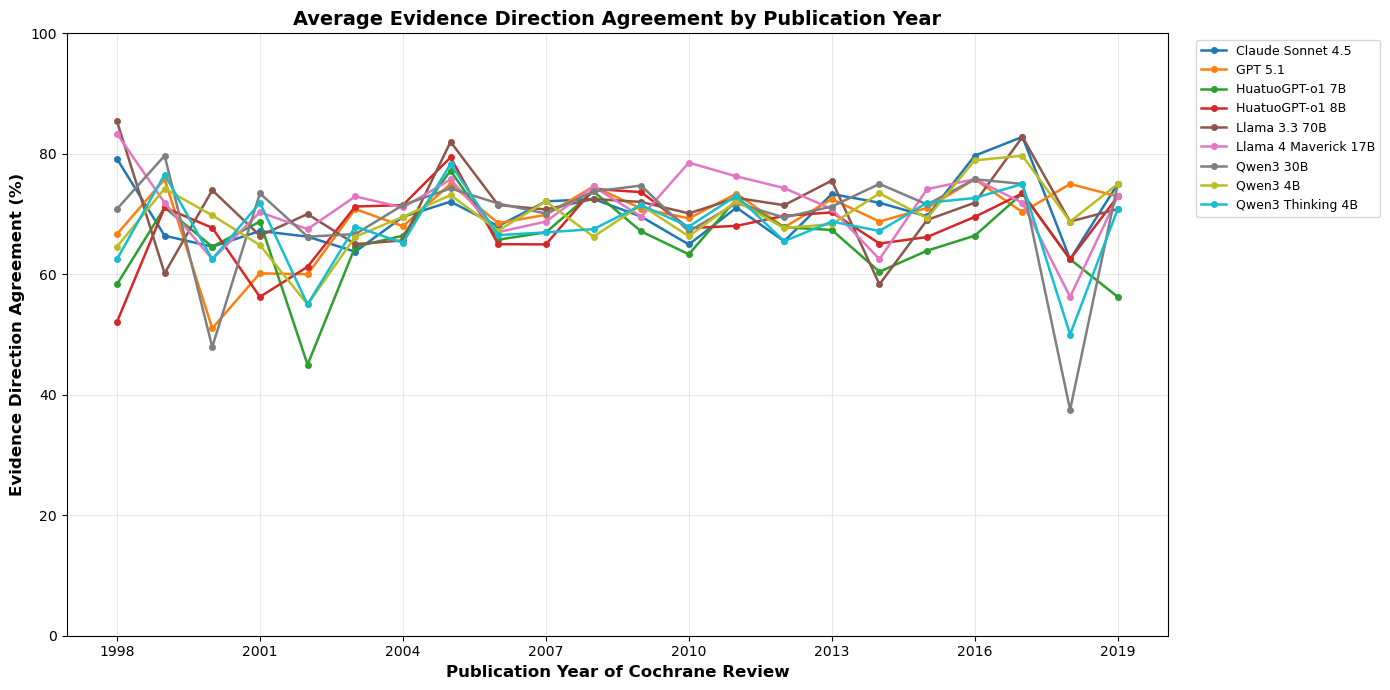

In [32]:
# ============================================================================
# BY-YEAR ANALYSIS EXECUTION
# ============================================================================

print("Loading year-level evidence direction agreement for all models...")
year_level_df = load_year_level_stats_for_all_models(model_names)

print("\nGenerating line plot...")
plot_evidence_direction_agreement_by_year(year_level_df)


## By Number of Sources